# TECH 405 – Week 2: Exploratory Data Analysis

## Smart Attendance System – Face Recognition

**Student: Amit**

The self-collected student face dataset is now available under `dataset/`. This notebook calculates the EDA results from the files at run time and excludes GUI assets in `collage_images/`.

In [2]:
from pathlib import Path
import hashlib
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

DATASET_DIR = Path("dataset")
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

def discover_images(root=DATASET_DIR):
    """Find supported images without ever scanning the GUI asset directory."""
    root = Path(root)
    if not root.exists() or not root.is_dir():
        return []
    return sorted(p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS)

def class_from_path(path, root=DATASET_DIR):
    try:
        relative = Path(path).relative_to(root)
        return relative.parts[0] if len(relative.parts) > 1 else ""
    except ValueError:
        return ""

image_paths = discover_images()
dataset_available = DATASET_DIR.exists() and bool(image_paths)
if not dataset_available:
    print("Dataset has not been collected yet. Add student face images to the dataset/ directory to populate this section.")

## 1. Dataset Card

- **Dataset name:** Smart Attendance System – Student Face Dataset
- **Source:** Self-collected for the TECH 405 Smart Attendance System project
- **Source link:** Not applicable – self-collected dataset
- **Licence:** Private academic dataset; not publicly licensed
- **Data type:** Grayscale student face images
- **Task:** Student face identification / recognition for automated attendance
- **Target:** Student identity
- **Current enrolled identities:** The current collection contains five student folders (calculated and verified below).
- **Size on disk, number of samples, and number of classes:** Calculated automatically below.

Observed current properties include five represented identities and a relatively small academic dataset. Possible risks include limited environmental diversity, similar collection conditions, lighting or pose bias, and limited generalization to unseen students. Privacy and informed-consent requirements remain important. These are limitations and risks to consider; equal image counts do not guarantee equal image quality or recognition difficulty.

In [3]:
def format_bytes(n):
    units = ["B", "KB", "MB", "GB"]
    value = float(n)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024

if image_paths:
    total_bytes = sum(p.stat().st_size for p in image_paths)
    classes = sorted({class_from_path(p) for p in image_paths if class_from_path(p)})
    card = pd.DataFrame({"Metric": ["Size on disk", "Number of samples", "Number of classes/students"],
                         "Value": [format_bytes(total_bytes), len(image_paths), len(classes)]})
    display(card)
else:
    print("Size, sample count, and class count: Pending dataset collection.")

,Metric,Value
0,Size on disk,2.10 MB
1,Number of samples,250
2,Number of classes/students,5


## 2. Data Loading and Initial Inspection

The expected layout is `dataset/student_id/image.ext`. The loader accepts JPG, JPEG, PNG, and WEBP files and records image metadata when Pillow can read it.

In [4]:
records = []
for path in image_paths:
    record = {"filepath": str(path), "filename": path.name, "class_name": class_from_path(path),
              "extension": path.suffix.lower(), "size_bytes": path.stat().st_size,
              "width": np.nan, "height": np.nan, "channels": np.nan, "image_mode": None}
    try:
        with Image.open(path) as img:
            record.update(width=img.width, height=img.height, image_mode=img.mode,
                          channels=len(img.getbands()))
    except (OSError, UnidentifiedImageError):
        pass
    records.append(record)

df = pd.DataFrame(records, columns=["filepath", "filename", "class_name", "extension", "size_bytes", "width", "height", "channels", "image_mode"])
print(f"Dataset shape: {df.shape}")
print(f"Number of classes: {df['class_name'].nunique() if not df.empty else 0}")
print("\nColumn data types:")
display(df.dtypes.to_frame("dtype"))
print("Directory/file structure summary:")
if df.empty:
    print("No supported dataset images found; structure summary is pending dataset collection.")
else:
    display(df.groupby("class_name", dropna=False).size().rename("image_count").to_frame())

Dataset shape: (250, 9)
Number of classes: 5

Column data types:


,dtype
filepath,object
filename,object
class_name,object
extension,object
size_bytes,int64
width,int64
height,int64
channels,int64
image_mode,object


Directory/file structure summary:


,image_count
class_name,
101,50
102,50
103,50
104,50
105,50


Random sample metadata:


,filepath,filename,class_name,extension,size_bytes,width,height,channels,image_mode
142,dataset\103\48.jpg,48.jpg,103,.jpg,8002,200,200,1,L
6,dataset\101\15.jpg,15.jpg,101,.jpg,7736,200,200,1,L
97,dataset\102\7.jpg,7.jpg,102,.jpg,9940,200,200,1,L
60,dataset\102\19.jpg,19.jpg,102,.jpg,10272,200,200,1,L
112,dataset\103\20.jpg,20.jpg,103,.jpg,7658,200,200,1,L


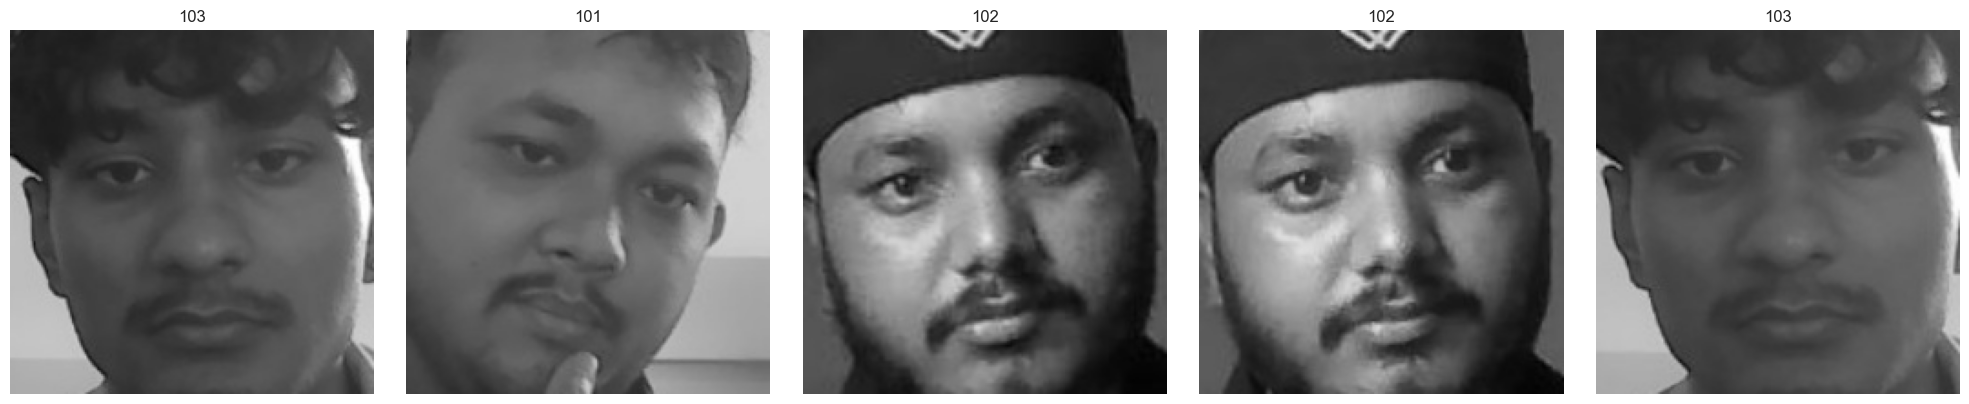

In [5]:
sample = df.sample(n=min(5, len(df)), random_state=RANDOM_STATE) if not df.empty else df
print("Random sample metadata:")
display(sample)
if sample.empty:
    print("Five random samples: Pending dataset collection.")
else:
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4), squeeze=False)
    for ax, (_, row) in zip(axes[0], sample.iterrows()):
        try:
            with Image.open(row["filepath"]) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(row["class_name"] or "Unlabelled")
        except (OSError, UnidentifiedImageError):
            ax.text(0.5, 0.5, "Unreadable image", ha="center", va="center")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 3. Data Quality Audit

Traditional tabular missing values are not the only concern for image data. This audit checks empty labels/folders, zero-byte files, missing image metadata, unreadable files, and exact duplicate files.

In [6]:
empty_class_labels = int((df["class_name"] == "").sum()) if not df.empty else 0
zero_byte_files = int((df["size_bytes"] == 0).sum()) if not df.empty else 0
missing_metadata = int(df[["width", "height", "channels", "image_mode"]].isna().any(axis=1).sum()) if not df.empty else 0
empty_class_folders = []
if DATASET_DIR.exists():
    empty_class_folders = [str(p) for p in DATASET_DIR.iterdir() if p.is_dir() and not any(q.is_file() and q.suffix.lower() in SUPPORTED_EXTENSIONS for q in p.rglob("*"))]
quality_summary = pd.DataFrame({"Check": ["Missing/empty class labels", "Empty class folders", "Zero-byte files", "Rows with missing image metadata"],
                                 "Count": [empty_class_labels, len(empty_class_folders), zero_byte_files, missing_metadata]})
display(quality_summary)
if empty_class_folders:
    print("Empty class folders:", empty_class_folders)
if df.empty:
    print("Data quality counts are pending dataset collection.")

,Check,Count
0,Missing/empty class labels,0
1,Empty class folders,0
2,Zero-byte files,0
3,Rows with missing image metadata,0


In [7]:
corrupt_rows = []
hash_to_paths = {}
for path in image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hash_to_paths.setdefault(digest, []).append(str(path))
    except (OSError, UnidentifiedImageError, ValueError) as exc:
        corrupt_rows.append({"filepath": str(path), "error": type(exc).__name__})
corrupt_df = pd.DataFrame(corrupt_rows, columns=["filepath", "error"])
duplicate_groups = [paths for paths in hash_to_paths.values() if len(paths) > 1]
duplicate_files = sum(len(paths) - 1 for paths in duplicate_groups)
print(f"Valid images: {len(image_paths) - len(corrupt_df)}")
print(f"Corrupt/unreadable images: {len(corrupt_df)}")
display(corrupt_df if not corrupt_df.empty else pd.DataFrame({"Result": ["No corrupt files found in available data."]}))
print(f"Unique file-content hashes: {len(hash_to_paths)}")
print(f"Duplicate files beyond the first in each exact group: {duplicate_files}")
if duplicate_groups:
    display(pd.DataFrame({"duplicate_group": range(1, len(duplicate_groups) + 1), "paths": duplicate_groups}))
else:
    print("No exact duplicate groups found in available data." if image_paths else "Duplicate analysis is pending dataset collection.")
print("Intended treatment: Corrupt or unreadable images will be excluded from modelling and, where possible, recollected.")
print("Intended treatment: Exact duplicate images will be removed before model training to prevent artificial inflation of the dataset and leakage between data splits.")
print("Perceptual/near-duplicate detection may later be useful for almost identical consecutive webcam frames.")

Valid images: 250
Corrupt/unreadable images: 0


,Result
0,No corrupt files found in available data.


Unique file-content hashes: 250
Duplicate files beyond the first in each exact group: 0
No exact duplicate groups found in available data.
Intended treatment: Corrupt or unreadable images will be excluded from modelling and, where possible, recollected.
Intended treatment: Exact duplicate images will be removed before model training to prevent artificial inflation of the dataset and leakage between data splits.
Perceptual/near-duplicate detection may later be useful for almost identical consecutive webcam frames.


## 4. Class Distribution

The target variable is **student identity**. Counts and interpretation below are computed from the available dataset; no imbalance is assumed before collection.

,image_count
class_name,
101,50
102,50
103,50
104,50
105,50


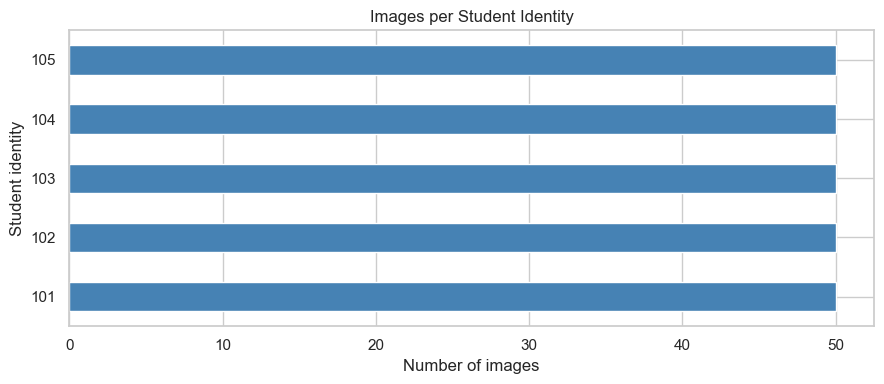

,Statistic,Value
0,Smallest class,50.0
1,Largest class,50.0
2,Mean,50.0
3,Median,50.0
4,Maximum/minimum ratio,1.0


Computed interpretation: the current class counts are perfectly balanced at 50 images per identity.
Imbalance matters because classes with more samples can dominate training, while students with fewer images may have poorer recognition accuracy. Consider similar collection targets, more data for underrepresented students, appropriate augmentation, class weighting, or balanced sampling.


In [8]:
class_counts = df["class_name"].value_counts().sort_values(ascending=True) if not df.empty else pd.Series(dtype="int64", name="image_count")
if class_counts.empty:
    print("Class distribution will be evaluated after face-image collection.")
else:
    display(class_counts.rename("image_count").to_frame())
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(class_counts))))
    class_counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Images per Student Identity")
    ax.set_xlabel("Number of images")
    ax.set_ylabel("Student identity")
    plt.tight_layout(); plt.show(); plt.close(fig)
    smallest, largest = class_counts.min(), class_counts.max()
    ratio = largest / smallest if smallest else np.nan
    stats = pd.DataFrame({"Statistic": ["Smallest class", "Largest class", "Mean", "Median", "Maximum/minimum ratio"],
                         "Value": [smallest, largest, class_counts.mean(), class_counts.median(), ratio]})
    display(stats)
    if ratio <= 1.5:
        print(f"Computed interpretation: the current class counts are perfectly balanced at {int(class_counts.iloc[0])} images per identity.")
    else:
        print("Computed interpretation: class sizes show potential imbalance by the 1.5× ratio rule.")
    print("Imbalance matters because classes with more samples can dominate training, while students with fewer images may have poorer recognition accuracy. Consider similar collection targets, more data for underrepresented students, appropriate augmentation, class weighting, or balanced sampling.")

## 5. Train / Validation / Test Split Plan

A starting plan is 70% training, 15% validation, and 15% test, adjusted for the final dataset size. For a closed-set enrolled-student identification system, every student should have sufficient representation in each split.

A naive random image-level split is risky when many images come from one webcam burst: nearly identical frames can appear in training and test, producing unrealistically high accuracy. The preferred approach is session-aware splitting within each student, for example `session_1 → train`, `session_2 → validation`, and `session_3 → test`. Collection should use multiple occasions and vary lighting, head pose, expression, distance, background, and time.

If the future goal changes to recognizing completely unseen identities with a verification/embedding model, evaluation by unseen identities may also be required. For this attendance system, the current assumption is enrolled-student identification.

In [9]:
def session_aware_split(metadata, session_col="session_id", class_col="class_name", seed=RANDOM_STATE):
    """Template: split complete capture sessions within each student.
    Requires one row per image and a session identifier; it does not perform a
    split without session metadata."""
    required = {session_col, class_col}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"Missing required metadata columns: {sorted(missing)}")
    rng = np.random.default_rng(seed)
    output = metadata.copy()
    output["split"] = None
    for student, group in output.groupby(class_col):
        sessions = list(group[session_col].dropna().unique())
        rng.shuffle(sessions)
        n = len(sessions)
        boundaries = [max(1, round(0.70*n)), max(1, round(0.85*n))]
        train_sessions, val_sessions = set(sessions[:boundaries[0]]), set(sessions[boundaries[0]:boundaries[1]])
        output.loc[group.index[group[session_col].isin(train_sessions)], "split"] = "train"
        output.loc[group.index[group[session_col].isin(val_sessions)], "split"] = "validation"
        output.loc[group.index[group[session_col].isin(set(sessions) - train_sessions - val_sessions)], "split"] = "test"
    return output

per_student = int(class_counts.iloc[0]) if not class_counts.empty else 0
train_n = round(0.70 * per_student); validation_n = round(0.15 * per_student); test_n = per_student - train_n - validation_n
print(f"Current split example per student: approximately {train_n} training, {validation_n} validation, and {test_n} test images from {per_student} images, following 70/15/15. No artificial split was performed in this notebook.")
print("Use session_aware_split(metadata) after adding a session_id column to the image metadata.")

Current split example per student: approximately 35 training, 8 validation, and 7 test images from 50 images, following 70/15/15. No artificial split was performed in this notebook.
Use session_aware_split(metadata) after adding a session_id column to the image metadata.


## 6. Model-Design Findings

### Findings status

The current dataset supports the following evidence-based model-design findings. These statements are based on the automatically computed EDA results for the present collection and should be revisited if the dataset changes.

- **Finding 1 – Resolution consistency:** All current images are 200 × 200 pixels. A 200 × 200 input is a reasonable initial preprocessing choice; resizing is not currently necessary, avoiding unnecessary interpolation.
- **Finding 2 – Balanced identities:** Each of the five student identities currently contributes 50 images, so class-count imbalance is not a current concern. Equal counts do not guarantee equal image quality, diversity, or recognition difficulty.
- **Finding 3 – Grayscale input:** All current images are grayscale with one channel. A one-channel model input is appropriate where supported; an RGB-only pretrained model would require channel repetition or conversion, and no color information is available.

The notebook continues to calculate these properties rather than relying on hard-coded values.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
width,250.0,NaN,NaN,NaN,200.0,0.0,200.0,200.0,200.0,200.0,200.0
height,250.0,NaN,NaN,NaN,200.0,0.0,200.0,200.0,200.0,200.0,200.0
aspect_ratio,250.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
channels,250.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
image_mode,250,1,L,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


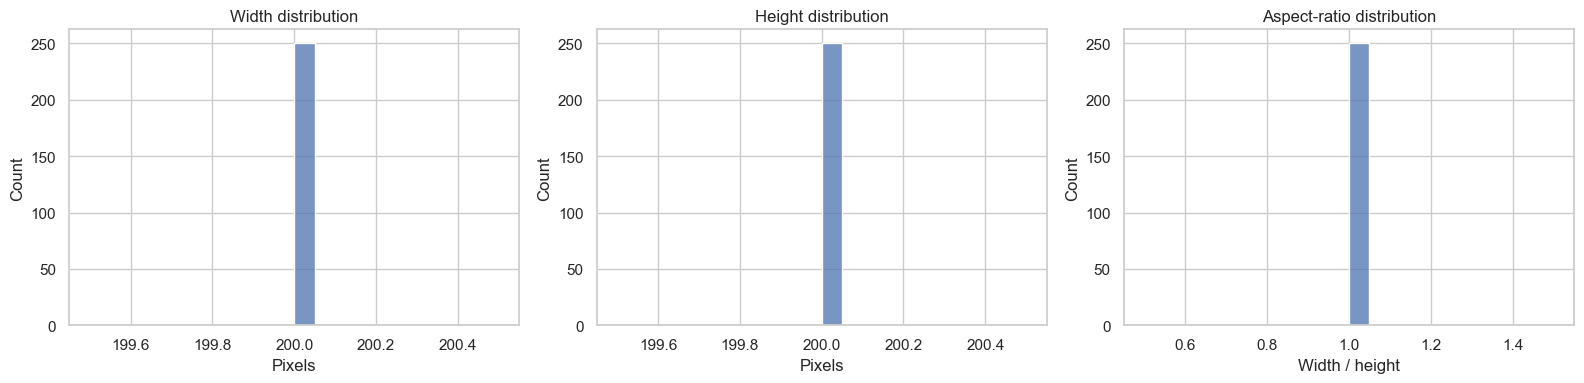

Image modes/channels:


,count
image_mode,
L,250


Computed hook: inspect these distributions before selecting a final target resolution; no resolution is recommended automatically without reviewing the collected data.
Computed evidence hook: no exact duplicates or unreadable metadata were detected in the available files; near-duplicate/session checks still require capture metadata.


In [10]:
if df.empty or df[["width", "height"]].dropna().empty:
    print("Resolution, aspect-ratio, channel, and mode findings are pending dataset collection.")
else:
    dimensions = df.dropna(subset=["width", "height"]).copy()
    dimensions["aspect_ratio"] = dimensions["width"] / dimensions["height"]
    display(dimensions[["width", "height", "aspect_ratio", "channels", "image_mode"]].describe(include="all").T)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.histplot(dimensions["width"], ax=axes[0], bins=20); axes[0].set_title("Width distribution"); axes[0].set_xlabel("Pixels")
    sns.histplot(dimensions["height"], ax=axes[1], bins=20); axes[1].set_title("Height distribution"); axes[1].set_xlabel("Pixels")
    sns.histplot(dimensions["aspect_ratio"], ax=axes[2], bins=20); axes[2].set_title("Aspect-ratio distribution"); axes[2].set_xlabel("Width / height")
    plt.tight_layout(); plt.show(); plt.close(fig)
    print("Image modes/channels:")
    display(dimensions["image_mode"].value_counts(dropna=False).rename("count").to_frame())
    print("Computed hook: inspect these distributions before selecting a final target resolution; no resolution is recommended automatically without reviewing the collected data.")
    if duplicate_files or len(dimensions) != len(df):
        print("Computed evidence hook: duplicate or unreadable-file risk is present and should inform session-aware collection/evaluation.")
    else:
        print("Computed evidence hook: no exact duplicates or unreadable metadata were detected in the available files; near-duplicate/session checks still require capture metadata.")

## One-Page EDA Summary

The Smart Attendance System uses self-collected face images to identify enrolled students for automated attendance. The current dataset contains 250 images across five student identities, with 50 images per class. The class distribution is therefore balanced at the sample-count level.

All current images are JPG files, 200 × 200 pixels, grayscale, and one-channel. The audit found 250 valid images, no corrupt or unreadable files, and no exact duplicate files. These checks remain implemented so future additions are audited automatically.

A 70%/15%/15% plan gives approximately 35 training images and 7–8 validation/test images per student. If images were captured as consecutive frames in one session, a naive image-level split could leak near-identical frames across train and test. Session-aware splitting is preferred; session metadata is not currently recorded, so leakage cannot be claimed to be eliminated.

The current 200 × 200 grayscale format simplifies preprocessing. Future evaluation should still consider capture diversity, lighting, pose, background, privacy, consent, and generalization beyond the five represented identities.

## Part A Completion Checklist

1. Dataset card — completed with current dataset details and automatically calculated metrics.
2. Shape/dtypes/file structure and five random samples — completed from the real dataset.
3. Missing, duplicate, and corrupt audit — completed; current audit found no corrupt or exact duplicate files.
4. Class distribution and imbalance discussion — completed; current sample counts are balanced.
5. Train/validation/test split plan — completed with session-leakage warning.
6. Three evidence-based model-design findings — completed for resolution, identity balance, and grayscale input.

## Part B – Image / Vision

This section analyzes the real student face dataset discovered in Part A. It reuses the existing metadata and excludes GUI assets in `collage_images/`.

### 1. Image Size and Channel Distribution

Image dimensions, aspect ratios, modes, and channel counts are summarized below when valid dataset images are available. These results will help determine preprocessing requirements.


,width,height,aspect_ratio
count,250.0,250.0,250.0
mean,200.0,200.0,1.0
std,0.0,0.0,0.0
min,200.0,200.0,1.0
25%,200.0,200.0,1.0
50%,200.0,200.0,1.0
75%,200.0,200.0,1.0
max,200.0,200.0,1.0


,class_name,filepath,width,height,aspect_ratio,mode,channels
0,101,dataset\101\1.jpg,200,200,1.0,L,1
1,101,dataset\101\10.jpg,200,200,1.0,L,1
2,101,dataset\101\11.jpg,200,200,1.0,L,1
3,101,dataset\101\12.jpg,200,200,1.0,L,1
4,101,dataset\101\13.jpg,200,200,1.0,L,1


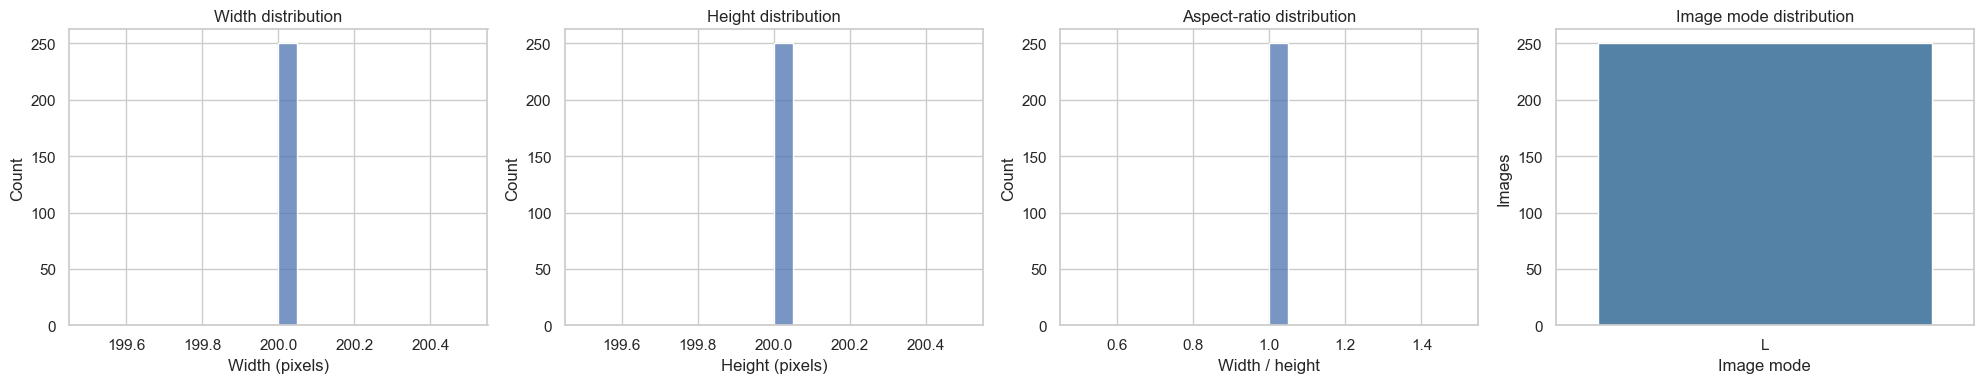

,image_count
channels,
1,250


In [11]:
vision_columns = ["class_name", "filepath", "width", "height", "aspect_ratio", "mode", "channels"]
vision_df = df.copy() if "df" in globals() else pd.DataFrame()
if not vision_df.empty:
    vision_df = vision_df.rename(columns={"image_mode": "mode"})
    for column in vision_columns:
        if column not in vision_df.columns:
            vision_df[column] = np.nan
    vision_df["aspect_ratio"] = vision_df["width"] / vision_df["height"]
    vision_df = vision_df[vision_columns]
    valid_vision_df = vision_df.dropna(subset=["width", "height", "channels"]).copy()
else:
    vision_df = pd.DataFrame(columns=vision_columns)
    valid_vision_df = vision_df.copy()

if valid_vision_df.empty:
    print("Image size and channel analysis is pending dataset collection.")
else:
    display(valid_vision_df[["width", "height", "aspect_ratio"]].describe())
    display(valid_vision_df[vision_columns].head())
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    sns.histplot(valid_vision_df["width"], bins=20, ax=axes[0]); axes[0].set_title("Width distribution"); axes[0].set_xlabel("Width (pixels)")
    sns.histplot(valid_vision_df["height"], bins=20, ax=axes[1]); axes[1].set_title("Height distribution"); axes[1].set_xlabel("Height (pixels)")
    sns.histplot(valid_vision_df["aspect_ratio"], bins=20, ax=axes[2]); axes[2].set_title("Aspect-ratio distribution"); axes[2].set_xlabel("Width / height")
    mode_counts = valid_vision_df["mode"].fillna("Unknown").value_counts()
    sns.barplot(x=mode_counts.index.astype(str), y=mode_counts.values, ax=axes[3], color="steelblue"); axes[3].set_title("Image mode distribution"); axes[3].set_xlabel("Image mode"); axes[3].set_ylabel("Images")
    plt.tight_layout(); plt.show(); plt.close(fig)
    display(valid_vision_df["channels"].value_counts().sort_index().rename("image_count").to_frame())

#### Target Resolution Decision

The final model input resolution must be selected after inspecting the real dimensions, aspect ratios, face detail, computational budget, and whether resizing or aspect-preserving cropping is appropriate. The EDA resolution below is only a decision aid; it is not automatically the final training resolution.


In [12]:
if valid_vision_df.empty:
    print("Final target resolution will be selected after the real face dataset is collected and inspected.")
else:
    dimension_summary = valid_vision_df[["width", "height"]].round().astype(int).mode()
    median_width = int(valid_vision_df["width"].median())
    median_height = int(valid_vision_df["height"].median())
    print(f"Most common width/height values, where available: {dimension_summary.to_dict(orient='records')}")
    print(f"Median dimensions: {median_width} × {median_height} pixels.")
    if (valid_vision_df["width"] == 200).all() and (valid_vision_df["height"] == 200).all():
        print("Evidence-based target resolution: 200 × 200 pixels. All current images already have this size, so resizing is unnecessary and avoidable interpolation can be minimized.")
    else:
        print("Recommendation hook: use a practical, aspect-preserving input size supported by the common dimensions and available face detail; do not stretch images. Review the actual distributions before finalizing it.")

Most common width/height values, where available: [{'width': 200, 'height': 200}]
Median dimensions: 200 × 200 pixels.
Evidence-based target resolution: 200 × 200 pixels. All current images already have this size, so resizing is unnecessary and avoidable interpolation can be minimized.


### 2. Sample Images Per Class

Visual inspection helps identify whether each student has enough variation in lighting, pose, expression, camera distance, background, blur, and occlusion. No dataset-specific visual claim is made until real images are available.


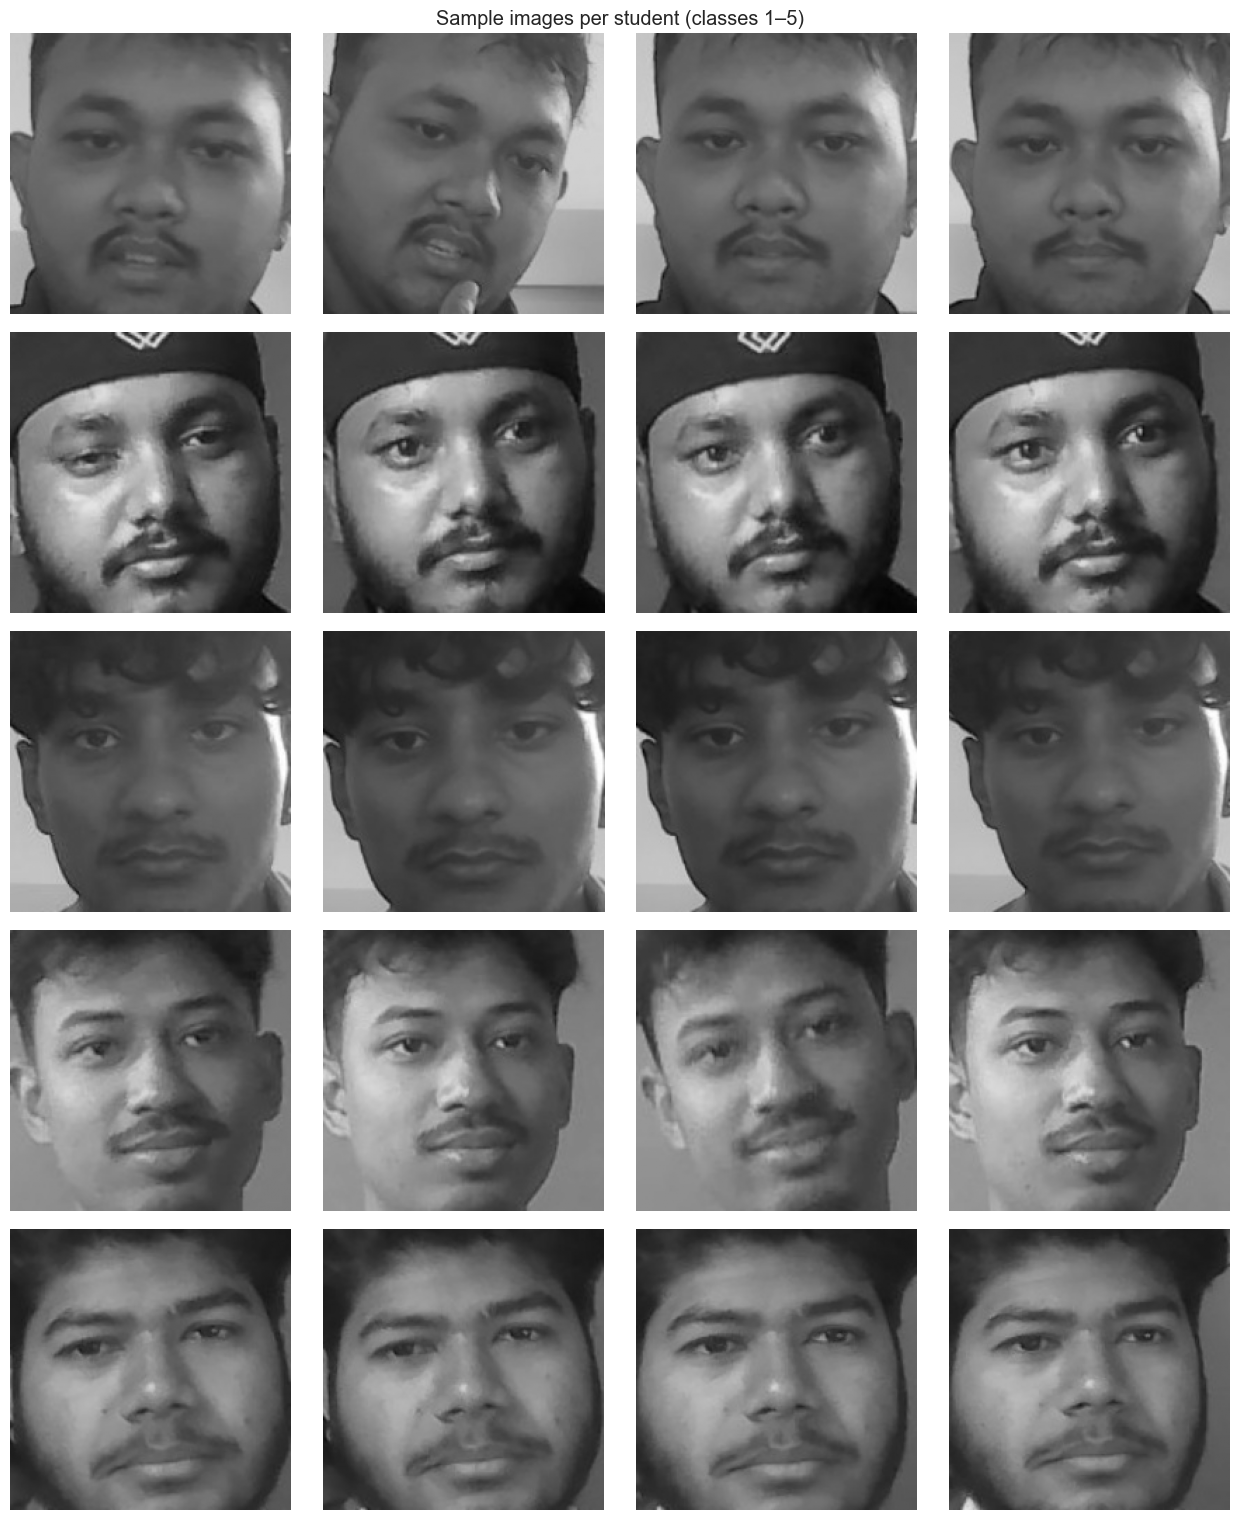

In [13]:
def show_samples_per_class(metadata, samples_per_class=4, classes_per_batch=6, seed=RANDOM_STATE):
    if metadata.empty or "class_name" not in metadata.columns:
        print("Sample grid pending dataset collection.")
        return
    rng = np.random.default_rng(seed)
    class_names = sorted(c for c in metadata["class_name"].dropna().unique() if str(c))
    for batch_start in range(0, len(class_names), classes_per_batch):
        batch = class_names[batch_start:batch_start + classes_per_batch]
        fig, axes = plt.subplots(len(batch), samples_per_class, figsize=(3.2 * samples_per_class, 3.1 * len(batch)), squeeze=False)
        for row_index, class_name in enumerate(batch):
            rows = metadata[metadata["class_name"] == class_name]
            selected = rows.iloc[rng.choice(len(rows), size=min(samples_per_class, len(rows)), replace=False)] if len(rows) else rows
            for col_index, (_, item) in enumerate(selected.iterrows()):
                ax = axes[row_index, col_index]
                try:
                    with Image.open(item["filepath"]) as image:
                        ax.imshow(image, cmap="gray" if image.mode == "L" else None, vmin=0 if image.mode == "L" else None, vmax=255 if image.mode == "L" else None)
                except (OSError, UnidentifiedImageError):
                    ax.text(0.5, 0.5, "Unreadable", ha="center", va="center")
                ax.axis("off")
            axes[row_index, 0].set_ylabel(str(class_name), rotation=0, labelpad=45, va="center")
            for col_index in range(len(selected), samples_per_class):
                axes[row_index, col_index].axis("off")
        fig.suptitle(f"Sample images per student (classes {batch_start + 1}–{batch_start + len(batch)})")
        plt.tight_layout(); plt.show(); plt.close(fig)

show_samples_per_class(vision_df)

### 3. Pixel Intensity Distribution Per Class

For a computationally manageable comparison, each readable image is converted to grayscale and resized to a small analysis size before its intensity values are summarized. Pixel values use a consistent 0–255 range. Differences can motivate later normalization or augmentation, but no issue is claimed without evidence.


,class_name,mean_intensity,std_intensity,min_intensity,max_intensity
0,101,108.328765,37.508379,30,226
1,102,91.105903,49.811062,2,238
2,103,85.202549,39.720782,18,255
3,104,108.289282,42.597589,16,217
4,105,98.044248,38.481852,18,225


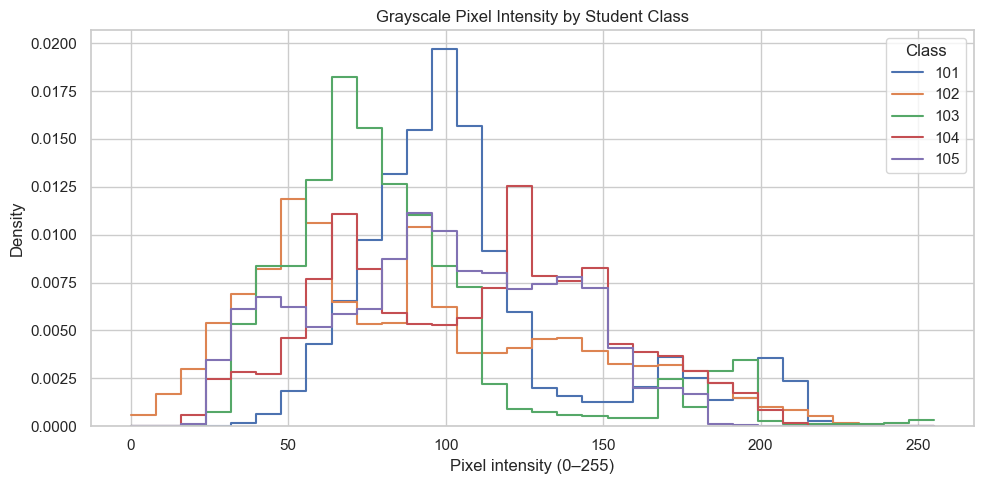

In [14]:
def intensity_statistics_by_class(metadata, max_images_per_class=50, analysis_size=(64, 64), seed=RANDOM_STATE):
    if metadata.empty:
        return pd.DataFrame(columns=["class_name", "mean_intensity", "std_intensity", "min_intensity", "max_intensity"]), {}
    rng = np.random.default_rng(seed)
    stats, values_by_class = [], {}
    for class_name, group in metadata.groupby("class_name"):
        chosen = group.iloc[rng.choice(len(group), size=min(max_images_per_class, len(group)), replace=False)]
        values = []
        for _, item in chosen.iterrows():
            try:
                with Image.open(item["filepath"]) as image:
                    values.append(np.asarray(image.convert("L").resize(analysis_size), dtype=np.uint8).ravel())
            except (OSError, UnidentifiedImageError):
                continue
        if values:
            pixels = np.concatenate(values)
            values_by_class[str(class_name)] = pixels
            stats.append({"class_name": class_name, "mean_intensity": pixels.mean(), "std_intensity": pixels.std(), "min_intensity": pixels.min(), "max_intensity": pixels.max()})
    return pd.DataFrame(stats), values_by_class

intensity_df, intensity_values = intensity_statistics_by_class(vision_df)
if intensity_df.empty:
    print("Pixel intensity analysis pending dataset collection.")
else:
    display(intensity_df)
    class_names = list(intensity_values)
    for start in range(0, len(class_names), 6):
        batch = class_names[start:start + 6]
        fig, ax = plt.subplots(figsize=(10, 5))
        for class_name in batch:
            sns.histplot(intensity_values[class_name], bins=32, binrange=(0, 255), stat="density", element="step", fill=False, label=class_name, ax=ax)
        ax.set_title("Grayscale Pixel Intensity by Student Class")
        ax.set_xlabel("Pixel intensity (0–255)"); ax.set_ylabel("Density"); ax.legend(title="Class")
        plt.tight_layout(); plt.show(); plt.close(fig)

### 4. Mean Image Per Class

A mean image requires equal spatial dimensions. Because face images may differ in size, each readable image is converted to RGB and resized to the fixed EDA-only resolution `MEAN_IMAGE_SIZE = (128, 128)` before pixel-wise averaging. This visualization resolution is not the final training resolution. Mean images can reveal alignment, background, lighting, pose, and variation patterns, but dataset-specific conclusions require real images.


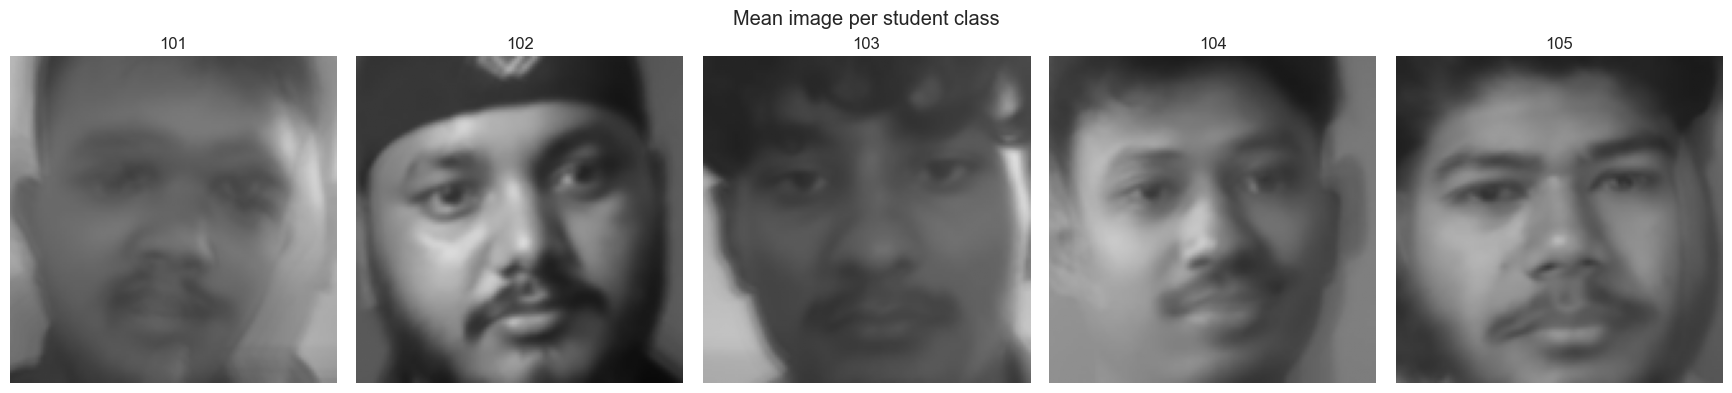

In [15]:
MEAN_IMAGE_SIZE = (128, 128)
def compute_mean_image(filepaths, size=MEAN_IMAGE_SIZE):
    arrays = []
    for filepath in filepaths:
        try:
            with Image.open(filepath) as image:
                arrays.append(np.asarray(image.convert("L").resize(size), dtype=np.float32))
        except (OSError, UnidentifiedImageError):
            continue
    return np.mean(arrays, axis=0).astype(np.uint8) if arrays else None

def show_mean_images_per_class(metadata, classes_per_batch=6):
    if metadata.empty:
        print("Mean-image analysis pending dataset collection.")
        return
    grouped = list(metadata.groupby("class_name"))
    for start in range(0, len(grouped), classes_per_batch):
        batch = grouped[start:start + classes_per_batch]
        fig, axes = plt.subplots(1, len(batch), figsize=(3.5 * len(batch), 4), squeeze=False)
        for index, (class_name, group) in enumerate(batch):
            mean_image = compute_mean_image(group["filepath"].tolist())
            if mean_image is not None:
                axes[0, index].imshow(mean_image, cmap="gray", vmin=0, vmax=255)
            else:
                axes[0, index].text(0.5, 0.5, "No readable images", ha="center", va="center")
            axes[0, index].set_title(str(class_name)); axes[0, index].axis("off")
        fig.suptitle("Mean image per student class")
        plt.tight_layout(); plt.show(); plt.close(fig)

show_mean_images_per_class(vision_df)

### Implications for Face Recognition

The Image/Vision results can guide preprocessing and model design: inconsistent dimensions may require resizing; inconsistent aspect ratios call for aspect-preserving transforms rather than uncontrolled stretching; grayscale/RGB differences require standardized channels; lighting differences may motivate brightness/contrast augmentation; low within-student variation may require more diverse collection; overly consistent backgrounds can create background shortcuts; large images may need resizing for computational efficiency; and blurry or unreadable images should be excluded or recollected. The statements above are design considerations, not claims about this dataset.


In [16]:
if valid_vision_df.empty:
    print("Face-recognition preprocessing implications are pending dataset collection.")
else:
    if valid_vision_df[["width", "height"]].nunique().max() > 1:
        print("Observed implication: image dimensions vary; resizing will be required, with aspect-preserving transforms considered.")
    if valid_vision_df["aspect_ratio"].nunique() > 1:
        print("Observed implication: aspect ratios vary; avoid uncontrolled stretching during preprocessing.")
    if valid_vision_df["channels"].nunique() > 1:
        print("Observed implication: channel counts vary; standardize all inputs to a common channel format.")
    if intensity_df.empty:
        print("No readable intensity data is available for further interpretation.")
    else:
        print("Computed intensity summaries are available above; inspect class differences before choosing normalization or augmentation.")
    print("These observations should be combined with visual inspection and capture-session metadata before changing the model pipeline.")

Computed intensity summaries are available above; inspect class differences before choosing normalization or augmentation.
These observations should be combined with visual inspection and capture-session metadata before changing the model pipeline.



# Week 4
# TECH 405 – Neural Network Classification

## Smart Attendance System – CNN Face Classifier


This section continues directly from the Week 2 EDA above. It reuses the same
`dataset/` directory, the same discovered image metadata (`df`), the same class
names (student identity folders), and the same `RANDOM_STATE` seed.

Plan for this part of the assignment:

1. Preprocess the same images into a CNN-ready tensor (resize, normalize, encode labels).
2. Split the data into stratified training / validation / test sets.
3. Augment the training data only.
4. Build a configurable CNN with reusable helper functions.
5. Train a baseline model and four hyperparameter experiments.
6. Select the final model on **validation** performance.
7. Evaluate the selected model on the held-out test set with a confusion matrix,
   precision, recall, and F-score.

## Environment, Seeds, and GPU Check

TensorFlow/Keras is imported here. The physical devices detected by TensorFlow are
printed so it is clear whether training ran on a GPU or on the CPU. All random
seeds are fixed to `RANDOM_STATE` (42, already defined in the EDA section) so the
experiments are reproducible.

In [17]:
import random
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

# Reproducibility: RANDOM_STATE (42) was defined in the EDA section above.
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

gpu_devices = tf.config.list_physical_devices("GPU")
cpu_devices = tf.config.list_physical_devices("CPU")
print(f"\nGPU devices detected by TensorFlow: {gpu_devices}")
print(f"CPU devices detected by TensorFlow: {cpu_devices}")

if gpu_devices:
    # Memory growth is enabled so TensorFlow does not reserve the whole GPU up front.
    for gpu in gpu_devices:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as exc:
            print(f"Memory-growth setting skipped for {gpu.name}: {exc}")
    TRAIN_DEVICE = "/GPU:0"
    print(f"\nTraining device: {TRAIN_DEVICE} (GPU acceleration is available and will be used).")
else:
    TRAIN_DEVICE = "/CPU:0"
    print("\nTraining device: /CPU:0 (TensorFlow detected no GPU, so training runs on the CPU).")
    print("The dataset is small (250 images at 128 x 128), so CPU training stays practical.")

TensorFlow version : 2.18.0
Keras version      : 3.7.0

GPU devices detected by TensorFlow: []
CPU devices detected by TensorFlow: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Training device: /CPU:0 (TensorFlow detected no GPU, so training runs on the CPU).
The dataset is small (250 images at 128 x 128), so CPU training stays practical.


## Preparing the Week 2 Dataset for the CNN

The same images analysed in the EDA are loaded again, this time as a numeric array.

Preprocessing decisions, and the EDA evidence behind each one:

- **Target size 128 x 128.** EDA Finding 1 showed every image is 200 x 200, so a
  square resize introduces no aspect-ratio distortion. 128 x 128 keeps enough facial
  detail while reducing the pixels per image by about 59%, which keeps the CNN
  experiments fast.
- **Grayscale, 1 channel.** EDA Finding 3 showed every image is single-channel
  grayscale, so the model input shape is `(128, 128, 1)`. There is no colour
  information to discard.
- **Normalization to 0–1.** Pixel values are divided by 255.0 so the inputs match the
  scale on which the ReLU/Adam combination trains most stably.
- **Label encoding.** The class folder names (student IDs) are encoded to integers
  0..N-1 with `LabelEncoder`, which is what `sparse_categorical_crossentropy` expects.

In [18]:
IMG_SIZE = (128, 128)      # CNN input height and width
IMG_CHANNELS = 1           # grayscale, confirmed by EDA Finding 3
INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS)

# Reuse the metadata table built in the EDA section; keep only readable, labelled images.
model_df = df.dropna(subset=["width", "height"]).copy()
model_df = model_df[model_df["class_name"].astype(str) != ""].reset_index(drop=True)
print(f"Images available for modelling: {len(model_df)} of {len(df)} discovered files")

def load_image_array(filepath, size=IMG_SIZE):
    """Load one image as a normalized float32 grayscale array of shape (H, W, 1)."""
    with Image.open(filepath) as image:
        resized = image.convert("L").resize(size, Image.BILINEAR)
        array = np.asarray(resized, dtype=np.float32) / 255.0
    return array[..., np.newaxis]

X = np.stack([load_image_array(path) for path in model_df["filepath"]]).astype("float32")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_df["class_name"].astype(str)).astype("int32")
CLASS_NAMES = [str(name) for name in label_encoder.classes_]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nX shape            : {X.shape}  (samples, height, width, channels)")
print(f"y shape            : {y.shape}")
print(f"X dtype            : {X.dtype}")
print(f"Pixel value range  : {X.min():.3f} to {X.max():.3f}")
print(f"Number of classes  : {NUM_CLASSES}")
print(f"Class names        : {CLASS_NAMES}")

label_mapping = pd.DataFrame({
    "encoded_label": range(NUM_CLASSES),
    "class_name (student id)": CLASS_NAMES,
    "images_in_dataset": [int((y == index).sum()) for index in range(NUM_CLASSES)],
})
print("\nLabel mapping:")
display(label_mapping)

Images available for modelling: 250 of 250 discovered files

X shape            : (250, 128, 128, 1)  (samples, height, width, channels)
y shape            : (250,)
X dtype            : float32
Pixel value range  : 0.004 to 1.000
Number of classes  : 5
Class names        : ['101', '102', '103', '104', '105']

Label mapping:


,encoded_label,class_name (student id),images_in_dataset
0,0,101,50
1,1,102,50
2,2,103,50
3,3,104,50
4,4,105,50


## Train / Validation / Test Split (70 / 15 / 15)

The split follows the plan written in EDA section 5: roughly 70% training, 15%
validation, and 15% test. Two stratified `train_test_split` calls are used so each
student keeps the same proportion in every split, and `random_state=RANDOM_STATE`
makes the split reproducible.

The **test set is touched only once**, in the final evaluation. Model selection uses
the validation set only.

In [19]:
# First split: 70% train, 30% holdout (stratified by student).
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE, shuffle=True)

# Second split: the 30% holdout is halved into 15% validation and 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, stratify=y_holdout,
    random_state=RANDOM_STATE, shuffle=True)

total_images = len(X)
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "Total"],
    "Images": [len(X_train), len(X_val), len(X_test), total_images],
    "Percentage": [f"{100 * len(X_train) / total_images:.1f}%",
                   f"{100 * len(X_val) / total_images:.1f}%",
                   f"{100 * len(X_test) / total_images:.1f}%",
                   "100.0%"],
})
print("Split sizes:")
display(split_summary)

distribution = pd.DataFrame(
    {"Train": [int((y_train == i).sum()) for i in range(NUM_CLASSES)],
     "Validation": [int((y_val == i).sum()) for i in range(NUM_CLASSES)],
     "Test": [int((y_test == i).sum()) for i in range(NUM_CLASSES)]},
    index=pd.Index(CLASS_NAMES, name="class_name (student id)"))
distribution["Total"] = distribution.sum(axis=1)
print("\nClass distribution per split (stratified):")
display(distribution)

print(f"Shapes -> X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"Shapes -> y_train {y_train.shape}, y_val {y_val.shape}, y_test {y_test.shape}")
assert len(X_train) + len(X_val) + len(X_test) == total_images, "Splits must sum to the dataset size"

Split sizes:


,Split,Images,Percentage
0,Train,175,70.0%
1,Validation,37,14.8%
2,Test,38,15.2%
3,Total,250,100.0%



Class distribution per split (stratified):


,Train,Validation,Test,Total
class_name (student id),,,,
101,35,7,8,50
102,35,8,7,50
103,35,7,8,50
104,35,7,8,50
105,35,8,7,50


Shapes -> X_train (175, 128, 128, 1), X_val (37, 128, 128, 1), X_test (38, 128, 128, 1)
Shapes -> y_train (175,), y_val (37,), y_test (38,)


## Dataset Limitation: Image-Level Splitting

The images in `dataset/` were captured as **consecutive webcam frames** for each
student, and the EDA recorded no `session_id` metadata. The split above is therefore
an **image-level** split, not a session-level split.

Why this matters:

- Neighbouring frames from one capture burst are nearly identical: same lighting,
  same background, same pose, same clothing, and only milliseconds apart.
- A random image-level split can place frame *n* in the training set and frame
  *n + 1* in the test set. The model can then score highly by recognizing the capture
  session rather than the person's face.
- The resulting test accuracy is therefore **optimistic**. It measures "can the model
  re-identify frames from a session it has already seen", not "can the model recognize
  this student on a different day".

A **session-based split** — whole capture sessions assigned to train, validation, or
test, as implemented by `session_aware_split()` in EDA section 5 — would give a far
more honest estimate. That function is ready to use as soon as a `session_id` column
is recorded during collection. Every accuracy reported below should be read with this
caveat in mind.

## Data Augmentation (Training Data Only)

Augmentation is applied **only to the training set**. The validation and test sets are
left untouched so that the reported metrics measure performance on unmodified images.

The transformations are deliberately conservative and chosen to match real webcam
attendance conditions:

| Transformation | Setting | Reason |
|---|---|---|
| Horizontal flip | on | A mirrored face is still a valid face, so this is safe and doubles the effective pose variety. |
| Rotation | ±6% (about ±22°) | Students tilt their head slightly at the camera. |
| Translation | ±8% of height and width | The face is not always perfectly centred in the frame. |
| Zoom | ±10% | Students sit closer to or further from the webcam. |
| Brightness | ±15% | The EDA pixel-intensity histograms showed lighting differences between students. |

Augmentation is implemented as Keras preprocessing layers inside the `tf.data`
pipeline and runs with `training=True` for the training dataset only.

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=RANDOM_STATE),
    layers.RandomRotation(0.06, fill_mode="nearest", seed=RANDOM_STATE),
    layers.RandomTranslation(0.08, 0.08, fill_mode="nearest", seed=RANDOM_STATE),
    layers.RandomZoom(0.10, 0.10, fill_mode="nearest", seed=RANDOM_STATE),
    layers.RandomBrightness(0.15, value_range=(0.0, 1.0), seed=RANDOM_STATE),
], name="training_augmentation")

def make_dataset(features, labels, batch_size=32, augment=False, shuffle=False,
                 seed=RANDOM_STATE):
    """Build a tf.data pipeline. Augmentation is applied only when augment=True."""
    dataset = tf.data.Dataset.from_tensor_slices((features, labels))
    if shuffle:
        dataset = dataset.shuffle(len(features), seed=seed, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size)
    if augment:
        dataset = dataset.map(
            lambda batch_x, batch_y: (data_augmentation(batch_x, training=True), batch_y),
            num_parallel_calls=AUTOTUNE)
    return dataset.prefetch(AUTOTUNE)

print("Augmentation pipeline (training data only):")
for layer in data_augmentation.layers:
    print(f"  - {layer.__class__.__name__}")
print("\nValidation and test pipelines are built with augment=False, so they stay unmodified.")

Augmentation pipeline (training data only):
  - RandomFlip
  - RandomRotation
  - RandomTranslation
  - RandomZoom
  - RandomBrightness

Validation and test pipelines are built with augment=False, so they stay unmodified.


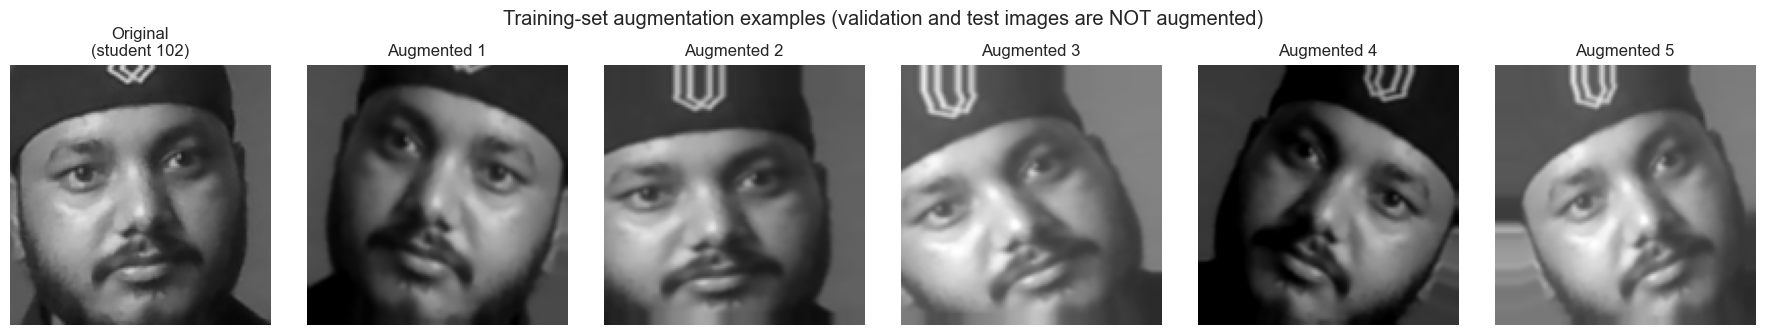

In [21]:
# Visual check: the same training image after several random augmentations.
sample_image = X_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(18, 3.4))
axes[0].imshow(sample_image[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Original\n(student {CLASS_NAMES[y_train[0]]})")
axes[0].axis("off")
for index in range(1, 6):
    augmented = data_augmentation(sample_image, training=True)
    axes[index].imshow(np.clip(np.asarray(augmented)[0, :, :, 0], 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[index].set_title(f"Augmented {index}")
    axes[index].axis("off")
fig.suptitle("Training-set augmentation examples (validation and test images are NOT augmented)")
plt.tight_layout(); plt.show(); plt.close(fig)

## Reusable CNN Builder and Experiment Runner

Rather than repeating the model code for every experiment, three reusable functions
are defined once and called with different hyperparameters:

- **`build_model(...)`** — assembles a configurable CNN: a stack of
  `Conv2D → Conv2D → MaxPooling2D → Dropout` blocks, then `GlobalAveragePooling2D`,
  a `Dense` head with `Dropout`, and a final `Dense(NUM_CLASSES, activation="softmax")`.
  It is compiled with the **Adam** optimizer and
  **`sparse_categorical_crossentropy`** (integer labels, as encoded in NN-1).
- **`run_experiment(...)`** — builds the model, creates the augmented training
  pipeline and the clean validation pipeline, trains with **EarlyStopping** and
  **ReduceLROnPlateau**, and records the configuration plus the results.
- **`plot_training_history(...)`** — draws the accuracy and loss curves for any run.

Three design choices are worth stating explicitly, because each one was driven by an
observed problem rather than by habit:

- **`GlobalAveragePooling2D` instead of `Flatten`.** It removes the large fully
  connected layer that would otherwise hold most of the parameters, which is an
  important regularizer on a 175-image training set.
- **A 120-epoch budget instead of the 40 in the assignment brief.** A first run of
  these experiments capped at 40 epochs left *all five* configurations still
  underfitting (training accuracy between 0.32 and 0.76, validation loss still above
  1.2 and falling). With 175 training images and a batch size of 32 there are only
  **6 gradient updates per epoch**, so 40 epochs is just 240 updates — far too few.
  EarlyStopping (patience 25, `restore_best_weights=True`) still decides when each run
  actually stops, so a configuration that converges early is not forced to train for
  120 epochs.
- **No `BatchNormalization`.** Batch normalization was tried as a faster alternative
  to the longer budget and it failed badly here: with only 6 steps per epoch the BN
  moving averages never converged, so the inference-time statistics did not match the
  training activations. Training accuracy climbed past 0.5 while validation loss sat
  at chance (1.61), and EarlyStopping restored the epoch-1 weights. The longer budget
  without BN is the configuration that actually trains on a dataset this small.

In [22]:
def build_model(input_shape=INPUT_SHAPE, num_classes=None, filters=(32, 64, 128),
                dropout=0.3, learning_rate=1e-3, dense_units=128, name="cnn"):
    """Build and compile a configurable CNN for grayscale face classification."""
    if num_classes is None:
        num_classes = NUM_CLASSES

    inputs = keras.Input(shape=input_shape, name="input_image")
    x = inputs
    for block_index, filter_count in enumerate(filters, start=1):
        x = layers.Conv2D(filter_count, 3, padding="same", activation="relu",
                          name=f"block{block_index}_conv1")(x)
        x = layers.Conv2D(filter_count, 3, padding="same", activation="relu",
                          name=f"block{block_index}_conv2")(x)
        x = layers.MaxPooling2D(2, name=f"block{block_index}_pool")(x)
        x = layers.Dropout(dropout / 2, name=f"block{block_index}_dropout")(x)

    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(dense_units, activation="relu", name="dense_head")(x)
    x = layers.Dropout(dropout, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def run_experiment(name, learning_rate=1e-3, batch_size=32, dropout=0.3,
                   filters=(32, 64, 128), dense_units=128, epochs=120,
                   patience=25, verbose=2):
    """Train one configuration and return its model, history, and summary metrics."""
    keras.backend.clear_session()
    keras.utils.set_random_seed(RANDOM_STATE)   # every experiment starts from the same seed

    model = build_model(filters=filters, dropout=dropout, learning_rate=learning_rate,
                        dense_units=dense_units, name=name.lower().replace(" ", "_"))

    train_ds = make_dataset(X_train, y_train, batch_size=batch_size, augment=True, shuffle=True)
    val_ds = make_dataset(X_val, y_val, batch_size=batch_size, augment=False, shuffle=False)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10,
                                          min_lr=1e-6, verbose=1),
    ]

    print(f"\n{'=' * 78}\nExperiment: {name}")
    print(f"learning_rate={learning_rate} | batch_size={batch_size} | dropout={dropout} | "
          f"filters={filters} | max_epochs={epochs}\n{'=' * 78}")

    start_time = time.time()
    with tf.device(TRAIN_DEVICE):
        history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                            callbacks=callbacks, verbose=verbose)
    elapsed = time.time() - start_time

    hist = history.history
    best_index = int(np.argmin(hist["val_loss"]))   # the epoch EarlyStopping restores
    result = {
        "Experiment": name,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Dropout": dropout,
        "Filters": "-".join(str(f) for f in filters),
        "Parameters": int(model.count_params()),
        "Epochs Trained": len(hist["loss"]),
        "Best Epoch": best_index + 1,
        "Best Train Acc": float(np.max(hist["accuracy"])),
        "Train Acc @ Best Epoch": float(hist["accuracy"][best_index]),
        "Val Acc @ Best Epoch": float(hist["val_accuracy"][best_index]),
        "Best Val Acc": float(np.max(hist["val_accuracy"])),
        "Min Val Loss": float(np.min(hist["val_loss"])),
        "Train Time (s)": round(elapsed, 1),
    }
    print(f"\nFinished '{name}' in {elapsed:.1f}s | epochs trained: {result['Epochs Trained']} "
          f"| weights restored from epoch {result['Best Epoch']} "
          f"| val_acc of restored weights: {result['Val Acc @ Best Epoch']:.4f} "
          f"| best val_acc at any epoch: {result['Best Val Acc']:.4f} "
          f"| min val_loss: {result['Min Val Loss']:.4f}")
    return {"name": name, "model": model, "history": hist, "result": result}


def plot_training_history(history, title="Training history"):
    """Plot training vs validation accuracy and loss for one run."""
    epochs_range = range(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    axes[0].plot(epochs_range, history["accuracy"], "o-", label="Training accuracy", markersize=3)
    axes[0].plot(epochs_range, history["val_accuracy"], "s-", label="Validation accuracy", markersize=3)
    axes[0].set_title(f"{title} – Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0, 1.05); axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history["loss"], "o-", label="Training loss", markersize=3)
    axes[1].plot(epochs_range, history["val_loss"], "s-", label="Validation loss", markersize=3)
    axes[1].set_title(f"{title} – Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right"); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show(); plt.close(fig)

print("Reusable functions defined: build_model(), run_experiment(), plot_training_history()")

Reusable functions defined: build_model(), run_experiment(), plot_training_history()


## Baseline Model

The baseline configuration is the starting point every later experiment is compared
against:

| Hyperparameter | Value |
|---|---|
| Learning rate | 0.001 (Adam default) |
| Batch size | 32 |
| Dropout | 0.3 in the head, 0.15 after each conv block |
| Filters | 32 → 64 → 128 |
| Max epochs | 120 (EarlyStopping decides the real stopping point) |
| Callbacks | EarlyStopping (patience 25, restores best weights), ReduceLROnPlateau (factor 0.5, patience 10) |

`model.summary()` is printed first so the architecture and parameter count are
available for the report.

In [23]:
baseline_model = build_model(filters=(32, 64, 128), dropout=0.3, learning_rate=1e-3,
                             name="baseline_cnn")
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,589 (1.16 MB)

 Trainable params: 303,589 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
EPOCHS = 120
experiments = {}

experiments["Baseline"] = run_experiment(
    "Baseline", learning_rate=1e-3, batch_size=32, dropout=0.3,
    filters=(32, 64, 128), epochs=EPOCHS)



Experiment: Baseline
learning_rate=0.001 | batch_size=32 | dropout=0.3 | filters=(32, 64, 128) | max_epochs=120
Epoch 1/120
6/6 - 4s - 673ms/step - accuracy: 0.1829 - loss: 1.6122 - val_accuracy: 0.2162 - val_loss: 1.6087 - learning_rate: 1.0000e-03
Epoch 2/120
6/6 - 2s - 350ms/step - accuracy: 0.1543 - loss: 1.6107 - val_accuracy: 0.1892 - val_loss: 1.6089 - learning_rate: 1.0000e-03
Epoch 3/120
6/6 - 2s - 357ms/step - accuracy: 0.2114 - loss: 1.6087 - val_accuracy: 0.1892 - val_loss: 1.6084 - learning_rate: 1.0000e-03
Epoch 4/120
6/6 - 2s - 366ms/step - accuracy: 0.1886 - loss: 1.6117 - val_accuracy: 0.2162 - val_loss: 1.6063 - learning_rate: 1.0000e-03
Epoch 5/120
6/6 - 2s - 349ms/step - accuracy: 0.2229 - loss: 1.6105 - val_accuracy: 0.2162 - val_loss: 1.6087 - learning_rate: 1.0000e-03
Epoch 6/120
6/6 - 2s - 362ms/step - accuracy: 0.2171 - loss: 1.6088 - val_accuracy: 0.1892 - val_loss: 1.6092 - learning_rate: 1.0000e-03
Epoch 7/120
6/6 - 2s - 358ms/step - accuracy: 0.1943 - los

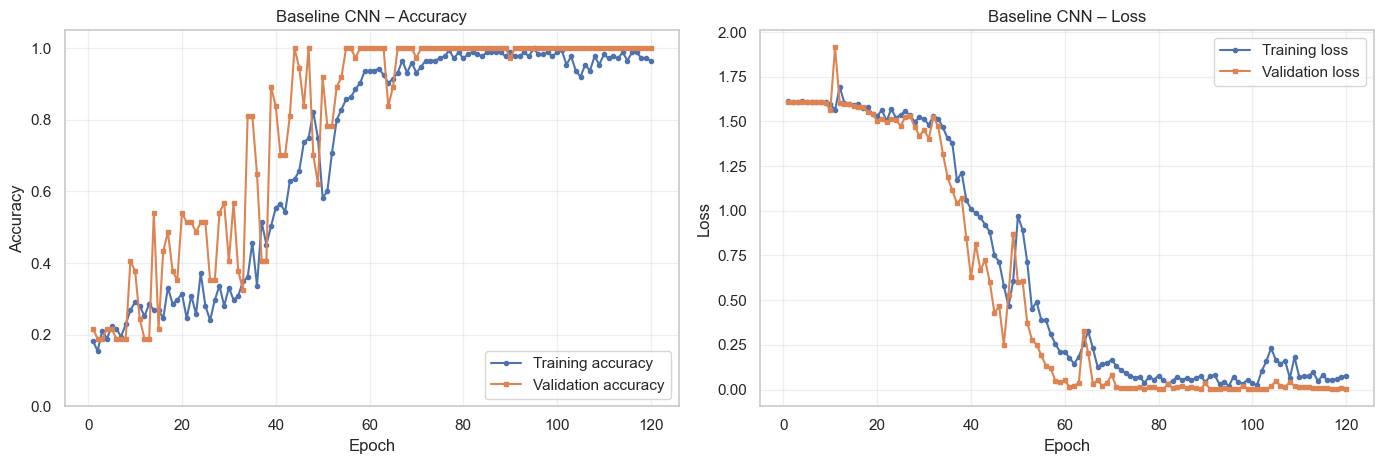

In [25]:
plot_training_history(experiments["Baseline"]["history"], title="Baseline CNN")

## Hyperparameter Experiments

Four further configurations are trained. Each changes **one** factor at a time
against the baseline, so any difference in validation performance can be attributed to
that factor:

| Experiment | Learning Rate | Batch Size | Dropout | Filters | What it tests |
|---|---:|---:|---:|---|---|
| Baseline | 0.001 | 32 | 0.3 | 32-64-128 | Reference configuration |
| Lower LR | 0.0001 | 32 | 0.3 | 32-64-128 | Does a 10× smaller step size train more stably, or just more slowly? |
| Higher Dropout | 0.001 | 32 | 0.5 | 32-64-128 | Does stronger regularization reduce overfitting on 175 training images? |
| Larger Model | 0.001 | 32 | 0.3 | 64-128-256 | Does more capacity help, or does it overfit the small dataset? |
| Larger Batch | 0.001 | 64 | 0.3 | 32-64-128 | Do fewer, smoother gradient updates per epoch help or hurt? |

All five runs use the same architecture family, the same 120-epoch budget, and the same
callbacks. Every run starts from the same seed and uses the same augmented training pipeline and
the same unaugmented validation set, so the comparison is fair.

In [26]:
experiments["Lower LR"] = run_experiment(
    "Lower LR", learning_rate=1e-4, batch_size=32, dropout=0.3,
    filters=(32, 64, 128), epochs=EPOCHS)


Experiment: Lower LR
learning_rate=0.0001 | batch_size=32 | dropout=0.3 | filters=(32, 64, 128) | max_epochs=120
Epoch 1/120
6/6 - 4s - 665ms/step - accuracy: 0.2000 - loss: 1.6094 - val_accuracy: 0.1892 - val_loss: 1.6091 - learning_rate: 1.0000e-04
Epoch 2/120
6/6 - 2s - 352ms/step - accuracy: 0.1429 - loss: 1.6098 - val_accuracy: 0.1892 - val_loss: 1.6090 - learning_rate: 1.0000e-04
Epoch 3/120
6/6 - 2s - 339ms/step - accuracy: 0.1886 - loss: 1.6091 - val_accuracy: 0.1892 - val_loss: 1.6089 - learning_rate: 1.0000e-04
Epoch 4/120
6/6 - 2s - 334ms/step - accuracy: 0.1714 - loss: 1.6087 - val_accuracy: 0.1892 - val_loss: 1.6088 - learning_rate: 1.0000e-04
Epoch 5/120
6/6 - 2s - 336ms/step - accuracy: 0.1771 - loss: 1.6093 - val_accuracy: 0.1892 - val_loss: 1.6088 - learning_rate: 1.0000e-04
Epoch 6/120
6/6 - 2s - 343ms/step - accuracy: 0.2171 - loss: 1.6072 - val_accuracy: 0.1892 - val_loss: 1.6086 - learning_rate: 1.0000e-04
Epoch 7/120
6/6 - 2s - 330ms/step - accuracy: 0.1829 - los

In [27]:
experiments["Higher Dropout"] = run_experiment(
    "Higher Dropout", learning_rate=1e-3, batch_size=32, dropout=0.5,
    filters=(32, 64, 128), epochs=EPOCHS)


Experiment: Higher Dropout
learning_rate=0.001 | batch_size=32 | dropout=0.5 | filters=(32, 64, 128) | max_epochs=120
Epoch 1/120
6/6 - 4s - 640ms/step - accuracy: 0.1714 - loss: 1.6105 - val_accuracy: 0.2162 - val_loss: 1.6076 - learning_rate: 1.0000e-03
Epoch 2/120
6/6 - 2s - 312ms/step - accuracy: 0.2000 - loss: 1.6142 - val_accuracy: 0.1892 - val_loss: 1.6082 - learning_rate: 1.0000e-03
Epoch 3/120
6/6 - 2s - 316ms/step - accuracy: 0.1771 - loss: 1.6087 - val_accuracy: 0.1892 - val_loss: 1.6083 - learning_rate: 1.0000e-03
Epoch 4/120
6/6 - 2s - 317ms/step - accuracy: 0.1714 - loss: 1.6086 - val_accuracy: 0.1892 - val_loss: 1.6078 - learning_rate: 1.0000e-03
Epoch 5/120
6/6 - 2s - 323ms/step - accuracy: 0.2229 - loss: 1.6087 - val_accuracy: 0.3784 - val_loss: 1.6080 - learning_rate: 1.0000e-03
Epoch 6/120
6/6 - 2s - 316ms/step - accuracy: 0.2229 - loss: 1.6063 - val_accuracy: 0.1892 - val_loss: 1.6059 - learning_rate: 1.0000e-03
Epoch 7/120
6/6 - 2s - 332ms/step - accuracy: 0.1714 

In [28]:
experiments["Larger Model"] = run_experiment(
    "Larger Model", learning_rate=1e-3, batch_size=32, dropout=0.3,
    filters=(64, 128, 256), epochs=EPOCHS)


Experiment: Larger Model
learning_rate=0.001 | batch_size=32 | dropout=0.3 | filters=(64, 128, 256) | max_epochs=120
Epoch 1/120
6/6 - 8s - 1s/step - accuracy: 0.2000 - loss: 1.6134 - val_accuracy: 0.2162 - val_loss: 1.6089 - learning_rate: 1.0000e-03
Epoch 2/120
6/6 - 6s - 1s/step - accuracy: 0.1771 - loss: 1.6101 - val_accuracy: 0.2162 - val_loss: 1.6093 - learning_rate: 1.0000e-03
Epoch 3/120
6/6 - 6s - 1s/step - accuracy: 0.1657 - loss: 1.6100 - val_accuracy: 0.1892 - val_loss: 1.6093 - learning_rate: 1.0000e-03
Epoch 4/120
6/6 - 6s - 1s/step - accuracy: 0.2171 - loss: 1.6091 - val_accuracy: 0.2162 - val_loss: 1.6093 - learning_rate: 1.0000e-03
Epoch 5/120
6/6 - 7s - 1s/step - accuracy: 0.1943 - loss: 1.6096 - val_accuracy: 0.2162 - val_loss: 1.6093 - learning_rate: 1.0000e-03
Epoch 6/120
6/6 - 7s - 1s/step - accuracy: 0.2114 - loss: 1.6096 - val_accuracy: 0.2162 - val_loss: 1.6089 - learning_rate: 1.0000e-03
Epoch 7/120
6/6 - 7s - 1s/step - accuracy: 0.1943 - loss: 1.6087 - val_a

In [29]:
experiments["Larger Batch"] = run_experiment(
    "Larger Batch", learning_rate=1e-3, batch_size=64, dropout=0.3,
    filters=(32, 64, 128), epochs=EPOCHS)


Experiment: Larger Batch
learning_rate=0.001 | batch_size=64 | dropout=0.3 | filters=(32, 64, 128) | max_epochs=120
Epoch 1/120
3/3 - 4s - 1s/step - accuracy: 0.2229 - loss: 1.6093 - val_accuracy: 0.1892 - val_loss: 1.6081 - learning_rate: 1.0000e-03
Epoch 2/120
3/3 - 2s - 597ms/step - accuracy: 0.1886 - loss: 1.6143 - val_accuracy: 0.1892 - val_loss: 1.6084 - learning_rate: 1.0000e-03
Epoch 3/120
3/3 - 2s - 657ms/step - accuracy: 0.2286 - loss: 1.6075 - val_accuracy: 0.1892 - val_loss: 1.6076 - learning_rate: 1.0000e-03
Epoch 4/120
3/3 - 2s - 612ms/step - accuracy: 0.2057 - loss: 1.6046 - val_accuracy: 0.1892 - val_loss: 1.6065 - learning_rate: 1.0000e-03
Epoch 5/120
3/3 - 2s - 616ms/step - accuracy: 0.2343 - loss: 1.6050 - val_accuracy: 0.1892 - val_loss: 1.6051 - learning_rate: 1.0000e-03
Epoch 6/120
3/3 - 2s - 696ms/step - accuracy: 0.2286 - loss: 1.6034 - val_accuracy: 0.1892 - val_loss: 1.6026 - learning_rate: 1.0000e-03
Epoch 7/120
3/3 - 2s - 635ms/step - accuracy: 0.2171 - los

## Experiment Comparison

The table below collects every configuration and its results.

One column needs explaining. **`Best Val Acc`** is the highest validation accuracy
reached at *any* epoch, but that peak can be a one-epoch fluctuation — the validation
set holds only 37 images, so a single image is worth 2.7 percentage points.
EarlyStopping restores the weights from the **lowest validation loss** epoch, so the
model that is actually kept is described by **`Val Acc @ Best Epoch`** and
**`Min Val Loss`**. Those are the columns used for selection; `Best Val Acc` is still
reported for completeness, and `Best Train Acc` / `Train Acc @ Best Epoch` make the
train-validation gap (the overfitting signal) visible.

In [30]:
comparison_df = pd.DataFrame([run["result"] for run in experiments.values()])
comparison_df = comparison_df[["Experiment", "Learning Rate", "Batch Size", "Dropout",
                               "Filters", "Parameters", "Epochs Trained", "Best Epoch",
                               "Best Train Acc", "Train Acc @ Best Epoch",
                               "Val Acc @ Best Epoch", "Best Val Acc", "Min Val Loss",
                               "Train Time (s)"]]
display(comparison_df.style.format({
    "Learning Rate": "{:.4f}", "Dropout": "{:.2f}", "Parameters": "{:,}",
    "Best Train Acc": "{:.4f}", "Train Acc @ Best Epoch": "{:.4f}",
    "Val Acc @ Best Epoch": "{:.4f}", "Best Val Acc": "{:.4f}",
    "Min Val Loss": "{:.4f}", "Train Time (s)": "{:.1f}",
}).background_gradient(subset=["Val Acc @ Best Epoch"], cmap="Greens")
 .set_caption("Hyperparameter experiment comparison"))

,Experiment,Learning Rate,Batch Size,Dropout,Filters,Parameters,Epochs Trained,Best Epoch,Best Train Acc,Train Acc @ Best Epoch,Val Acc @ Best Epoch,Best Val Acc,Min Val Loss,Train Time (s)
0,Baseline,0.0010,32,0.30,32-64-128,"303,589",120,101,1.0000,0.9943,1.0000,1.0000,0.0019,245.0
1,Lower LR,0.0001,32,0.30,32-64-128,"303,589",120,117,0.8286,0.8286,0.8919,0.9730,0.3363,239.8
2,Higher Dropout,0.0010,32,0.50,32-64-128,"303,589",120,118,0.9771,0.9714,1.0000,1.0000,0.0042,226.4
3,Larger Model,0.0010,32,0.30,64-128-256,"1,177,797",120,103,0.9829,0.9600,1.0000,1.0000,0.0112,765.2
4,Larger Batch,0.0010,64,0.30,32-64-128,"303,589",120,105,0.9886,0.9886,1.0000,1.0000,0.0103,232.2


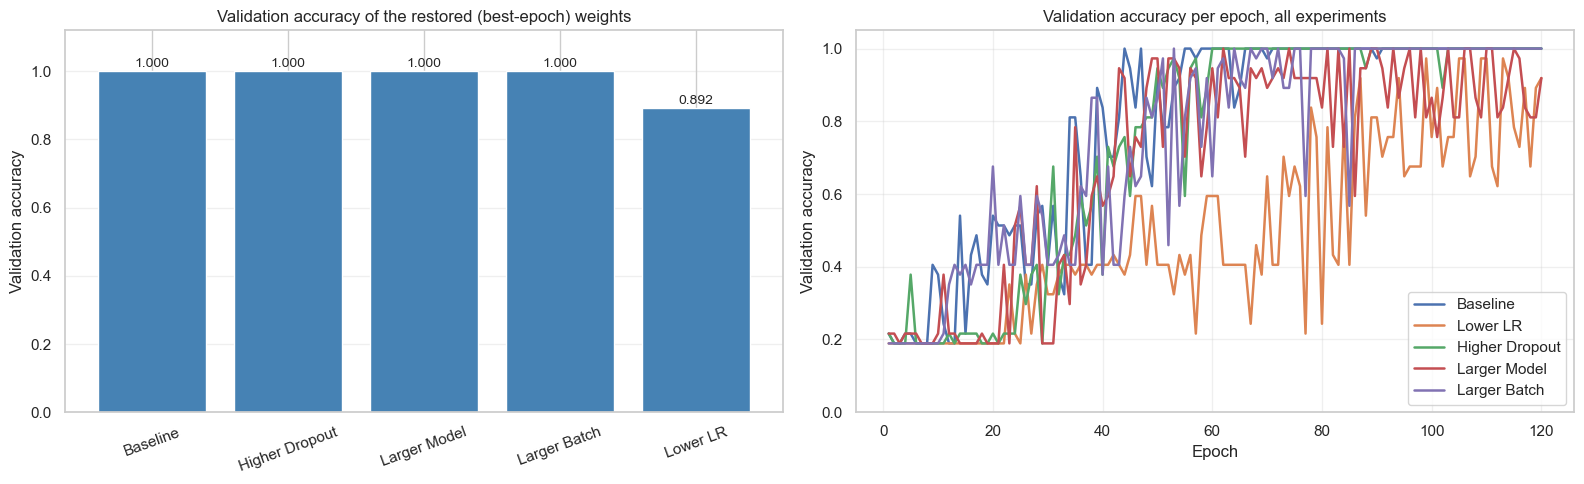

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = comparison_df.sort_values("Val Acc @ Best Epoch", ascending=False)
bars = axes[0].bar(order["Experiment"], order["Val Acc @ Best Epoch"], color="steelblue")
for bar, value in zip(bars, order["Val Acc @ Best Epoch"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.3f}",
                 ha="center", fontsize=10)
axes[0].set_title("Validation accuracy of the restored (best-epoch) weights")
axes[0].set_ylabel("Validation accuracy"); axes[0].set_ylim(0, 1.12)
axes[0].tick_params(axis="x", rotation=20); axes[0].grid(True, axis="y", alpha=0.3)

for name, run in experiments.items():
    axes[1].plot(range(1, len(run["history"]["val_accuracy"]) + 1),
                 run["history"]["val_accuracy"], label=name, linewidth=1.8)
axes[1].set_title("Validation accuracy per epoch, all experiments")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation accuracy")
axes[1].set_ylim(0, 1.05); axes[1].legend(loc="lower right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show(); plt.close(fig)

## Selecting the Final Model

Selection uses **validation performance only** — the test set is not consulted, which
would otherwise leak test information into the model choice and inflate the final
reported metrics.

The rule applied below is:

1. Take the highest **`Val Acc @ Best Epoch`** — the validation accuracy of the
   weights EarlyStopping actually restored, not a transient peak from some other epoch.
2. If several experiments tie on validation accuracy (likely here, because the
   validation set holds only 37 images, so a single image is worth about 2.7
   percentage points), break the tie with the **lowest `Min Val Loss`**. Lower
   validation loss means more confident, better-calibrated correct predictions.

In [32]:
ranked = comparison_df.sort_values(["Val Acc @ Best Epoch", "Min Val Loss"],
                                   ascending=[False, True]).reset_index(drop=True)
print("Experiments ranked by the validation accuracy of their restored weights, "
      "then by validation loss:")
display(ranked[["Experiment", "Val Acc @ Best Epoch", "Min Val Loss", "Best Val Acc",
                "Train Acc @ Best Epoch", "Epochs Trained", "Best Epoch"]])

top_accuracy = ranked.loc[0, "Val Acc @ Best Epoch"]
tied = ranked[np.isclose(ranked["Val Acc @ Best Epoch"], top_accuracy)]
SELECTED_NAME = ranked.loc[0, "Experiment"]
selected_run = experiments[SELECTED_NAME]
selected_model = selected_run["model"]
selected_config = selected_run["result"]

if len(tied) > 1:
    print(f"\n{len(tied)} experiments tied on validation accuracy ({top_accuracy:.4f}): "
          f"{list(tied['Experiment'])}")
    print(f"Tie broken by the lowest validation loss -> '{SELECTED_NAME}' "
          f"(val_loss {selected_config['Min Val Loss']:.4f}).")
else:
    print(f"\n'{SELECTED_NAME}' has the highest validation accuracy outright "
          f"({top_accuracy:.4f}); no tie-break was needed.")

print(f"\nSELECTED MODEL: {SELECTED_NAME}")
display(pd.DataFrame({"Setting": list(selected_config.keys()),
                      "Value": [str(v) for v in selected_config.values()]}))
selected_model.summary()

Experiments ranked by the validation accuracy of their restored weights, then by validation loss:


,Experiment,Val Acc @ Best Epoch,Min Val Loss,Best Val Acc,Train Acc @ Best Epoch,Epochs Trained,Best Epoch
0,Baseline,1.000000,0.001924,1.000000,0.994286,120,101
1,Higher Dropout,1.000000,0.004170,1.000000,0.971429,120,118
2,Larger Batch,1.000000,0.010255,1.000000,0.988571,120,105
3,Larger Model,1.000000,0.011232,1.000000,0.960000,120,103
4,Lower LR,0.891892,0.336251,0.972973,0.828571,120,117



4 experiments tied on validation accuracy (1.0000): ['Baseline', 'Higher Dropout', 'Larger Batch', 'Larger Model']
Tie broken by the lowest validation loss -> 'Baseline' (val_loss 0.0019).

SELECTED MODEL: Baseline


,Setting,Value
0,Experiment,Baseline
1,Learning Rate,0.001
2,Batch Size,32
3,Dropout,0.3
4,Filters,32-64-128
5,Parameters,303589
6,Epochs Trained,120
7,Best Epoch,101
8,Best Train Acc,1.0
9,Train Acc @ Best Epoch,0.9942857027053833


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910,769 (3.47 MB)

 Trainable params: 303,589 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 607,180 (2.32 MB)

## Final Evaluation on the Held-Out Test Set

The selected model now sees the test set for the first time. The test pipeline is
built with `augment=False`, so the images are exactly as preprocessed in NN-1.

Reported metrics:

- **Accuracy** — the overall proportion of correctly identified students.
- **Precision** — of the images predicted as student *k*, how many really were student
  *k*. Low precision in an attendance system means marking a student present who was
  not there.
- **Recall** — of the images that really were student *k*, how many were found. Low
  recall means failing to mark a present student.
- **F1-score** — the harmonic mean of precision and recall.

Both **macro** averages (every student counts equally) and **weighted** averages
(each student weighted by their number of test images) are reported. With a balanced
dataset the two are very close, but both are shown as required.

In [33]:
test_ds = make_dataset(X_test, y_test, batch_size=32, augment=False, shuffle=False)

test_loss, test_accuracy = selected_model.evaluate(test_ds, verbose=0)
y_pred_proba = selected_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_pred_confidence = np.max(y_pred_proba, axis=1)

accuracy = accuracy_score(y_test, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0)

print(f"Selected model      : {SELECTED_NAME}")
print(f"Test images         : {len(y_test)}")
print(f"Correct predictions : {int((y_pred == y_test).sum())} / {len(y_test)}")
print(f"Test loss           : {test_loss:.4f}\n")

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score",
               "Precision", "Recall", "F1-score"],
    "Average": ["-", "Macro", "Macro", "Macro", "Weighted", "Weighted", "Weighted"],
    "Value": [accuracy, macro_precision, macro_recall, macro_f1,
              weighted_precision, weighted_recall, weighted_f1],
})
final_metrics["Value"] = final_metrics["Value"].round(4)
print("FINAL TEST-SET METRICS")
display(final_metrics)

Selected model      : Baseline
Test images         : 38
Correct predictions : 38 / 38
Test loss           : 0.0058

FINAL TEST-SET METRICS


,Metric,Average,Value
0,Accuracy,-,1.0
1,Precision,Macro,1.0
2,Recall,Macro,1.0
3,F1-score,Macro,1.0
4,Precision,Weighted,1.0
5,Recall,Weighted,1.0
6,F1-score,Weighted,1.0


## Confusion Matrix

Rows are the **true** student, columns are the **predicted** student, and the class
labels are the real student-ID folder names from `dataset/`. Every value on the
diagonal is a correct identification; anything off the diagonal is a misidentified
student.

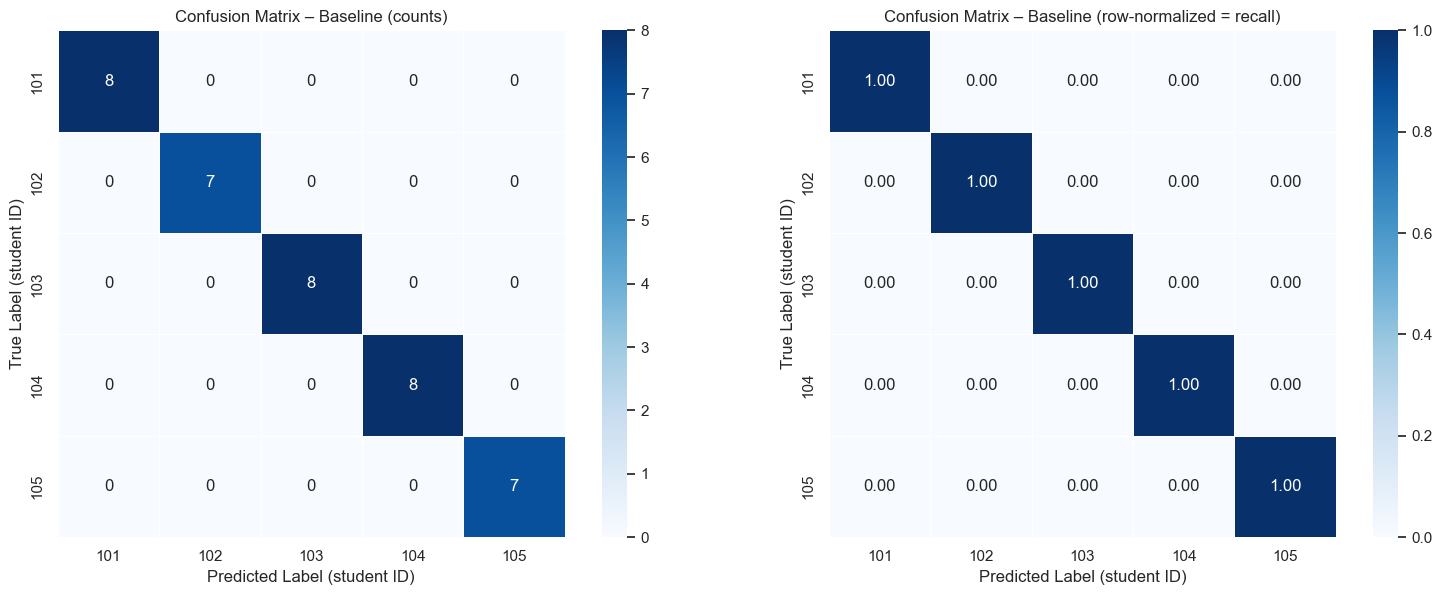

Confusion matrix as a table (rows = true student, columns = predicted student):


Predicted,101,102,103,104,105
True,,,,,
101,8,0,0,0,0
102,0,7,0,0,0
103,0,0,8,0,0
104,0,0,0,8,0
105,0,0,0,0,7



All 38 test images were classified correctly: the confusion matrix is purely diagonal, with no off-diagonal confusions between students.


In [34]:
cm = confusion_matrix(y_test, y_pred, labels=range(NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
            linewidths=0.5, linecolor="white")
axes[0].set_title(f"Confusion Matrix – {SELECTED_NAME} (counts)")
axes[0].set_xlabel("Predicted Label (student ID)")
axes[0].set_ylabel("True Label (student ID)")

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True,
            vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            linewidths=0.5, linecolor="white")
axes[1].set_title(f"Confusion Matrix – {SELECTED_NAME} (row-normalized = recall)")
axes[1].set_xlabel("Predicted Label (student ID)")
axes[1].set_ylabel("True Label (student ID)")

plt.tight_layout(); plt.show(); plt.close(fig)

print("Confusion matrix as a table (rows = true student, columns = predicted student):")
display(pd.DataFrame(cm, index=pd.Index(CLASS_NAMES, name="True"),
                     columns=pd.Index(CLASS_NAMES, name="Predicted")))

misclassified = int(cm.sum() - np.trace(cm))
if misclassified == 0:
    print(f"\nAll {len(y_test)} test images were classified correctly: the confusion matrix "
          f"is purely diagonal, with no off-diagonal confusions between students.")
else:
    print(f"\n{misclassified} of {len(y_test)} test images were misclassified. Off-diagonal pairs:")
    for true_index, predicted_index in zip(*np.where((cm > 0) & ~np.eye(NUM_CLASSES, dtype=bool))):
        print(f"  True {CLASS_NAMES[true_index]} -> predicted {CLASS_NAMES[predicted_index]}: "
              f"{cm[true_index, predicted_index]} image(s)")

## Classification Report

Per-student precision, recall, F1-score, and support (the number of test images that
truly belong to that student).

In [35]:
report_text = classification_report(y_test, y_pred, labels=range(NUM_CLASSES),
                                    target_names=CLASS_NAMES, digits=4, zero_division=0)
print(f"Classification report – {SELECTED_NAME} on the held-out test set\n")
print(report_text)

report_dict = classification_report(y_test, y_pred, labels=range(NUM_CLASSES),
                                    target_names=CLASS_NAMES, output_dict=True,
                                    zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df["support"] = report_df["support"].astype(int)
display(report_df.round(4))

Classification report – Baseline on the held-out test set

              precision    recall  f1-score   support

         101     1.0000    1.0000    1.0000         8
         102     1.0000    1.0000    1.0000         7
         103     1.0000    1.0000    1.0000         8
         104     1.0000    1.0000    1.0000         8
         105     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        38
   macro avg     1.0000    1.0000    1.0000        38
weighted avg     1.0000    1.0000    1.0000        38



,precision,recall,f1-score,support
101,1.0,1.0,1.0,8
102,1.0,1.0,1.0,7
103,1.0,1.0,1.0,8
104,1.0,1.0,1.0,8
105,1.0,1.0,1.0,7
accuracy,1.0,1.0,1.0,1
macro avg,1.0,1.0,1.0,38
weighted avg,1.0,1.0,1.0,38


## Training Curves for the Selected Model

Training versus validation accuracy and loss for the configuration that was selected.
The gap between the two curves is the overfitting signal: curves that stay close
together indicate the augmentation and dropout are holding overfitting in check, while
a validation loss that turns upward while the training loss keeps falling is the
classic overfitting pattern.

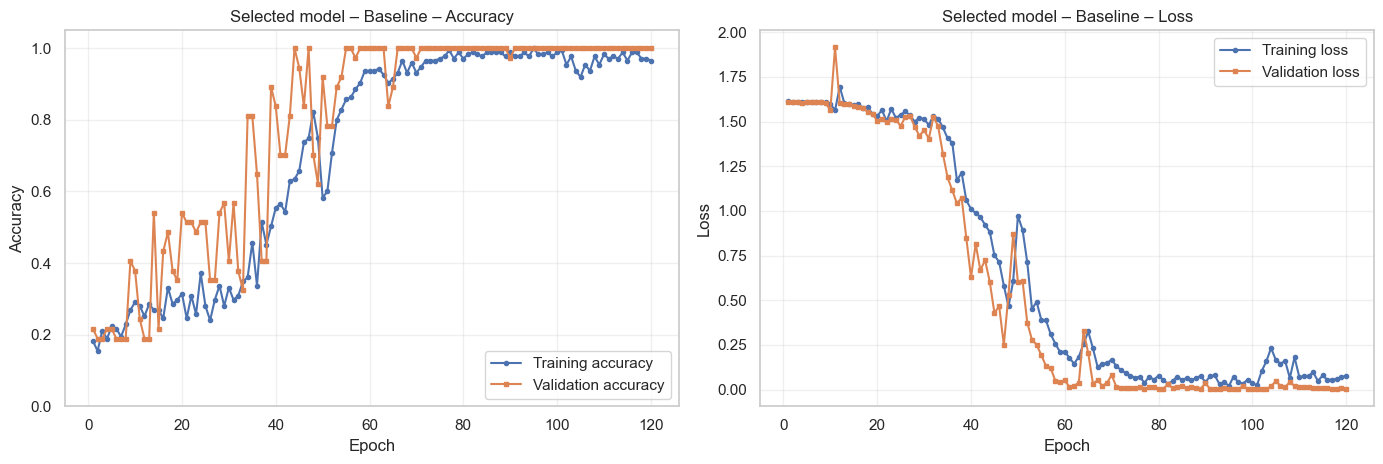

Epochs actually trained        : 120 (max was 120; EarlyStopping restored the weights from the best validation epoch)
Best validation-loss epoch     : 101
Final training accuracy        : 0.9657
Final validation accuracy      : 1.0000
Train - validation accuracy gap: -0.0343
Final training loss            : 0.0745
Final validation loss          : 0.0035
Minimum validation loss        : 0.0019

Interpretation: validation loss rose well above its minimum late in training, which is mild overfitting. EarlyStopping restored the best-epoch weights.


In [36]:
plot_training_history(selected_run["history"], title=f"Selected model – {SELECTED_NAME}")

history = selected_run["history"]
final_train_acc = history["accuracy"][-1]
final_val_acc = history["val_accuracy"][-1]
best_val_epoch = int(np.argmin(history["val_loss"])) + 1
gap = final_train_acc - final_val_acc

print(f"Epochs actually trained        : {len(history['loss'])} (max was {EPOCHS}; "
      f"EarlyStopping restored the weights from the best validation epoch)")
print(f"Best validation-loss epoch     : {best_val_epoch}")
print(f"Final training accuracy        : {final_train_acc:.4f}")
print(f"Final validation accuracy      : {final_val_acc:.4f}")
print(f"Train - validation accuracy gap: {gap:+.4f}")
print(f"Final training loss            : {history['loss'][-1]:.4f}")
print(f"Final validation loss          : {history['val_loss'][-1]:.4f}")
print(f"Minimum validation loss        : {min(history['val_loss']):.4f}")

if gap > 0.15:
    print("\nInterpretation: training accuracy is clearly above validation accuracy, "
          "so this run overfitted the small training set.")
elif history["val_loss"][-1] > min(history["val_loss"]) * 1.5:
    print("\nInterpretation: validation loss rose well above its minimum late in training, "
          "which is mild overfitting. EarlyStopping restored the best-epoch weights.")
else:
    print("\nInterpretation: the training and validation curves stayed close together, so no "
          "substantial overfitting is visible in this run. Note that the training curve is "
          "measured on augmented images while the validation curve is measured on clean ones, "
          "which is why validation accuracy can sit at or above training accuracy here.")

## Per-Class Performance

Precision, recall, and F1-score for each student side by side. This shows whether the
classifier is equally reliable for every enrolled student, or whether particular
students are harder to recognize.

,class_name (student id),Precision,Recall,F1-score,Support
0,101,1.0,1.0,1.0,8
1,102,1.0,1.0,1.0,7
2,103,1.0,1.0,1.0,8
3,104,1.0,1.0,1.0,8
4,105,1.0,1.0,1.0,7


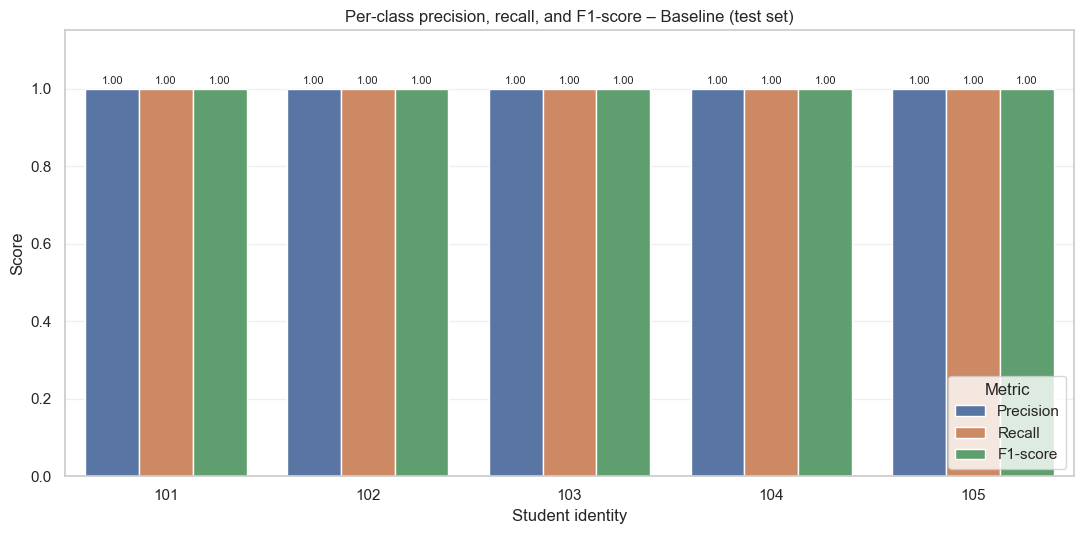

Every student reached the same F1-score (1.0000), so no student was measurably harder to classify on this test set.


In [37]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = \
    precision_recall_fscore_support(y_test, y_pred, labels=range(NUM_CLASSES),
                                    average=None, zero_division=0)

per_class_df = pd.DataFrame({
    "class_name (student id)": CLASS_NAMES,
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1-score": per_class_f1,
    "Support": per_class_support.astype(int),
})
display(per_class_df.round(4))

plot_df = per_class_df.melt(id_vars="class_name (student id)",
                            value_vars=["Precision", "Recall", "F1-score"],
                            var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=plot_df, x="class_name (student id)", y="Score", hue="Metric", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
ax.set_title(f"Per-class precision, recall, and F1-score – {SELECTED_NAME} (test set)")
ax.set_xlabel("Student identity"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.15)
ax.legend(title="Metric", loc="lower right"); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

weakest = per_class_df.loc[per_class_df["F1-score"].idxmin()]
strongest = per_class_df.loc[per_class_df["F1-score"].idxmax()]
if np.isclose(weakest["F1-score"], strongest["F1-score"]):
    print(f"Every student reached the same F1-score ({strongest['F1-score']:.4f}), so no "
          f"student was measurably harder to classify on this test set.")
else:
    print(f"Strongest class: {strongest['class_name (student id)']} (F1 = {strongest['F1-score']:.4f})")
    print(f"Weakest class  : {weakest['class_name (student id)']} (F1 = {weakest['F1-score']:.4f})")

## Prediction Examples

Test images with their true student, the predicted student, and the model's softmax
confidence. Correct predictions are titled in green and incorrect ones in red. If the
model made no mistakes on this test set, that is stated explicitly rather than
fabricating an error example.

Correct predictions  : 38 / 38
Incorrect predictions: 0 / 38


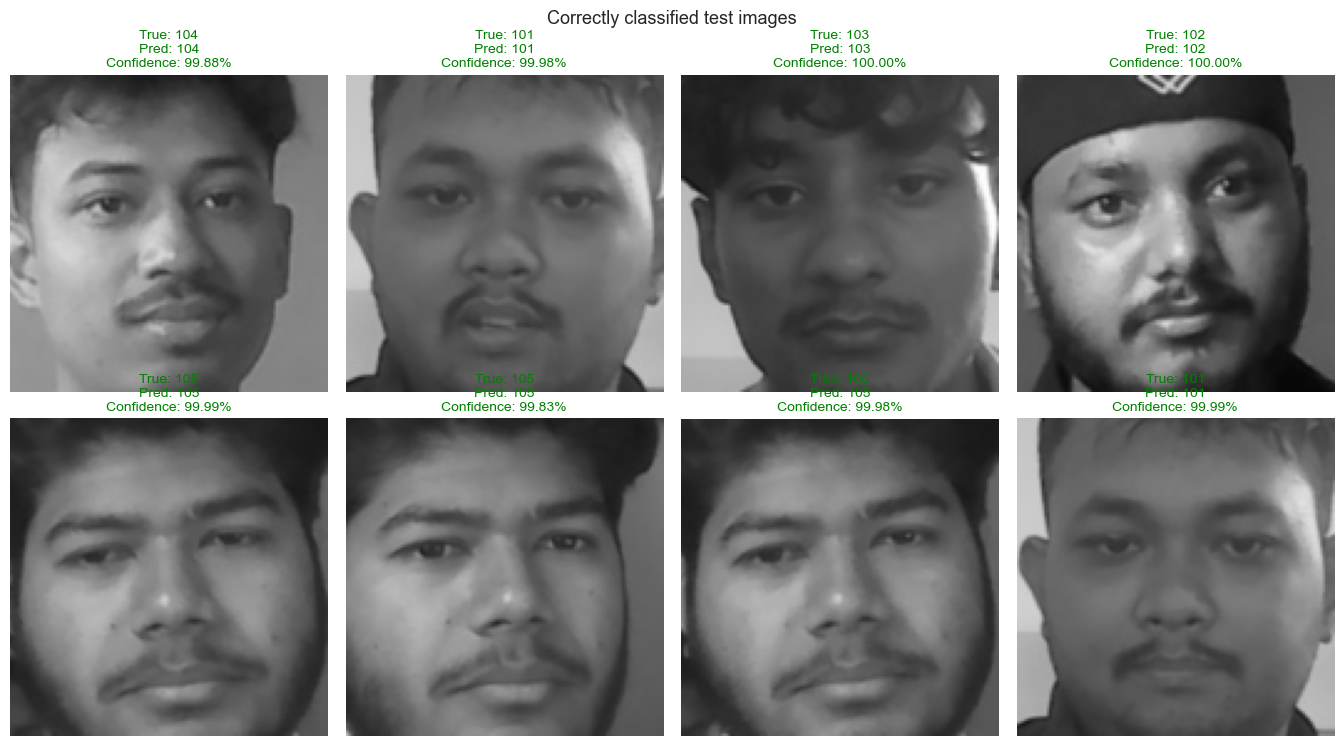


There are NO incorrect predictions on this test set: the selected model classified all 38 test images correctly, so no misclassified examples can be shown. No artificial error examples have been created.

Mean confidence on correct predictions  : 0.9943
Lowest confidence on any test image     : 0.9131 (true 105, predicted 105)


In [38]:
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]
print(f"Correct predictions  : {len(correct_indices)} / {len(y_test)}")
print(f"Incorrect predictions: {len(incorrect_indices)} / {len(y_test)}")

def show_prediction_grid(indices, title, columns=4):
    """Display test images annotated with true class, predicted class, and confidence."""
    if len(indices) == 0:
        return
    rows = int(np.ceil(len(indices) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(3.4 * columns, 3.8 * rows), squeeze=False)
    for position, index in enumerate(indices):
        ax = axes[position // columns, position % columns]
        ax.imshow(X_test[index, :, :, 0], cmap="gray", vmin=0, vmax=1)
        is_correct = y_pred[index] == y_test[index]
        ax.set_title(f"True: {CLASS_NAMES[y_test[index]]}\n"
                     f"Pred: {CLASS_NAMES[y_pred[index]]}\n"
                     f"Confidence: {y_pred_confidence[index]:.2%}",
                     color="green" if is_correct else "red", fontsize=10)
        ax.axis("off")
    for position in range(len(indices), rows * columns):
        axes[position // columns, position % columns].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show(); plt.close(fig)

rng = np.random.default_rng(RANDOM_STATE)
sample_correct = rng.choice(correct_indices, size=min(8, len(correct_indices)), replace=False)
sample_correct = np.sort(sample_correct)
show_prediction_grid(sample_correct, "Correctly classified test images")

if len(incorrect_indices) > 0:
    show_prediction_grid(incorrect_indices[:8], "Misclassified test images")
    print("\nAll misclassifications on the test set:")
    display(pd.DataFrame({
        "test_index": incorrect_indices,
        "true_class": [CLASS_NAMES[i] for i in y_test[incorrect_indices]],
        "predicted_class": [CLASS_NAMES[i] for i in y_pred[incorrect_indices]],
        "confidence": np.round(y_pred_confidence[incorrect_indices], 4),
    }))
else:
    print("\nThere are NO incorrect predictions on this test set: the selected model "
          f"classified all {len(y_test)} test images correctly, so no misclassified examples "
          "can be shown. No artificial error examples have been created.")

print(f"\nMean confidence on correct predictions  : {y_pred_confidence[correct_indices].mean():.4f}")
if len(incorrect_indices) > 0:
    print(f"Mean confidence on incorrect predictions: {y_pred_confidence[incorrect_indices].mean():.4f}")
print(f"Lowest confidence on any test image     : {y_pred_confidence.min():.4f} "
      f"(true {CLASS_NAMES[y_test[np.argmin(y_pred_confidence)]]}, "
      f"predicted {CLASS_NAMES[y_pred[np.argmin(y_pred_confidence)]]})")

## Metric Recap for the Report

This cell prints every number quoted in the written findings below in one block, so
the discussion can be checked against the values that were actually produced by this
run.

In [39]:
print("=" * 72)
print("RESULTS RECAP")
print("=" * 72)
print(f"Dataset          : {len(X)} images, {NUM_CLASSES} classes {CLASS_NAMES}")
print(f"Input shape      : {INPUT_SHAPE}, values scaled to 0-1")
print(f"Split            : {len(X_train)} train / {len(X_val)} validation / {len(X_test)} test")
print(f"Training device  : {TRAIN_DEVICE}")
print("-" * 72)
print("EXPERIMENTS (sorted by validation accuracy, then validation loss)")
print(ranked[["Experiment", "Learning Rate", "Batch Size", "Dropout", "Filters",
              "Epochs Trained", "Best Epoch", "Train Acc @ Best Epoch",
              "Val Acc @ Best Epoch", "Best Val Acc",
              "Min Val Loss"]].to_string(index=False))
print("-" * 72)
print(f"Selected model   : {SELECTED_NAME} "
      f"(val acc {selected_config['Val Acc @ Best Epoch']:.4f}, "
      f"val loss {selected_config['Min Val Loss']:.4f})")
print(f"Test accuracy    : {accuracy:.4f}")
print(f"Macro    P/R/F1  : {macro_precision:.4f} / {macro_recall:.4f} / {macro_f1:.4f}")
print(f"Weighted P/R/F1  : {weighted_precision:.4f} / {weighted_recall:.4f} / {weighted_f1:.4f}")
print(f"Test loss        : {test_loss:.4f}")
print(f"Misclassified    : {len(incorrect_indices)} of {len(y_test)} test images")
print("=" * 72)

RESULTS RECAP
Dataset          : 250 images, 5 classes ['101', '102', '103', '104', '105']
Input shape      : (128, 128, 1), values scaled to 0-1
Split            : 175 train / 37 validation / 38 test
Training device  : /CPU:0
------------------------------------------------------------------------
EXPERIMENTS (sorted by validation accuracy, then validation loss)
    Experiment  Learning Rate  Batch Size  Dropout    Filters  Epochs Trained  Best Epoch  Train Acc @ Best Epoch  Val Acc @ Best Epoch  Best Val Acc  Min Val Loss
      Baseline         0.0010          32      0.3  32-64-128             120         101                0.994286              1.000000      1.000000      0.001924
Higher Dropout         0.0010          32      0.5  32-64-128             120         118                0.971429              1.000000      1.000000      0.004170
  Larger Batch         0.0010          64      0.3  32-64-128             120         105                0.988571              1.000000      1

## Experimental Findings

The discussion below is **generated from the variables produced by this run**, so every
number quoted is a value the notebook actually computed. Re-running the notebook
regenerates the text along with the results.

In [40]:
from IPython.display import Markdown

def pct(value):
    return f"{value * 100:.2f}%"

# --- effect of each hyperparameter, measured against the baseline ---
by_name = comparison_df.set_index("Experiment")
baseline_row = by_name.loc["Baseline"]

def delta_sentence(experiment, changed):
    row = by_name.loc[experiment]
    acc_delta = row["Val Acc @ Best Epoch"] - baseline_row["Val Acc @ Best Epoch"]
    loss_delta = row["Min Val Loss"] - baseline_row["Min Val Loss"]
    direction = "improved" if acc_delta > 0 else ("reduced" if acc_delta < 0 else "left unchanged")
    return (f"- **{changed}** ({experiment}): validation accuracy "
            f"{pct(row['Val Acc @ Best Epoch'])} vs the baseline's "
            f"{pct(baseline_row['Val Acc @ Best Epoch'])} ({acc_delta:+.4f}), validation loss "
            f"{row['Min Val Loss']:.4f} vs {baseline_row['Min Val Loss']:.4f} "
            f"({loss_delta:+.4f}). This change **{direction}** validation accuracy.")

# --- overfitting check on the selected run ---
selected_history = selected_run["history"]
selected_gap = (selected_config["Train Acc @ Best Epoch"]
                - selected_config["Val Acc @ Best Epoch"])
final_val_loss = selected_history["val_loss"][-1]
min_val_loss = min(selected_history["val_loss"])
loss_rebound = final_val_loss - min_val_loss

if selected_gap > 0.15:
    overfit_text = (f"training accuracy at the restored epoch "
                    f"({pct(selected_config['Train Acc @ Best Epoch'])}) sits "
                    f"{selected_gap:.4f} above validation accuracy "
                    f"({pct(selected_config['Val Acc @ Best Epoch'])}), which is a clear "
                    f"overfitting gap on a 175-image training set")
elif loss_rebound > 0.3:
    overfit_text = (f"the train-validation accuracy gap is small ({selected_gap:+.4f}), but "
                    f"validation loss rose from its minimum of {min_val_loss:.4f} to "
                    f"{final_val_loss:.4f} by the last epoch (+{loss_rebound:.4f}), which is "
                    f"mild late-training overfitting. EarlyStopping restored the "
                    f"best-epoch weights, so the evaluated model is not the overfitted one")
else:
    overfit_text = (f"no substantial overfitting is visible: the train-validation accuracy "
                    f"gap at the restored epoch is only {selected_gap:+.4f} and validation "
                    f"loss ended at {final_val_loss:.4f} against a minimum of "
                    f"{min_val_loss:.4f}. Note that training accuracy is measured on "
                    f"*augmented* images while validation accuracy is measured on clean "
                    f"ones, so the training curve can legitimately sit below the "
                    f"validation curve here")

# --- per-class difficulty ---
sorted_classes = per_class_df.sort_values("F1-score", ascending=False)
if np.isclose(sorted_classes["F1-score"].min(), sorted_classes["F1-score"].max()):
    class_text = (f"Every student reached an identical F1-score of "
                  f"{sorted_classes['F1-score'].iloc[0]:.4f}, so on this test set no student "
                  f"was measurably harder to classify than another.")
else:
    best_row = sorted_classes.iloc[0]
    worst_row = sorted_classes.iloc[-1]
    class_text = (f"Student **{best_row['class_name (student id)']}** was the easiest to "
                  f"recognize (F1 = {best_row['F1-score']:.4f}, precision "
                  f"{best_row['Precision']:.4f}, recall {best_row['Recall']:.4f}), while "
                  f"student **{worst_row['class_name (student id)']}** was the hardest "
                  f"(F1 = {worst_row['F1-score']:.4f}, precision {worst_row['Precision']:.4f}, "
                  f"recall {worst_row['Recall']:.4f}).")

# --- confusion matrix ---
off_diagonal = [(CLASS_NAMES[t], CLASS_NAMES[p], int(cm[t, p]))
                for t, p in zip(*np.where((cm > 0) & ~np.eye(NUM_CLASSES, dtype=bool)))]
if not off_diagonal:
    cm_text = (f"The confusion matrix is entirely diagonal: all {len(y_test)} test images "
               f"fell on the correct row and column, so no student was ever mistaken for "
               f"another on this test set.")
else:
    pairs = "; ".join(f"true **{t}** predicted as **{p}** ({n} image{'s' if n > 1 else ''})"
                      for t, p, n in off_diagonal)
    cm_text = (f"The confusion matrix shows {len(incorrect_indices)} off-diagonal "
               f"entr{'ies' if len(off_diagonal) > 1 else 'y'}: {pairs}. Every other test "
               f"image fell on the diagonal.")

worst_experiment = ranked.iloc[-1]

findings = f"""
### Effect of each hyperparameter

All four variants below change exactly one factor against the baseline
(lr {baseline_row['Learning Rate']}, batch {int(baseline_row['Batch Size'])},
dropout {baseline_row['Dropout']}, filters {baseline_row['Filters']}), which trained for
{int(baseline_row['Epochs Trained'])} epochs and reached
{pct(baseline_row['Val Acc @ Best Epoch'])} validation accuracy at its restored epoch
{int(baseline_row['Best Epoch'])}.

{delta_sentence("Lower LR", "Learning rate 0.001 -> 0.0001")}
{delta_sentence("Higher Dropout", "Dropout 0.3 -> 0.5")}
{delta_sentence("Larger Model", "Filters 32-64-128 -> 64-128-256")}
{delta_sentence("Larger Batch", "Batch size 32 -> 64")}

**Learning rate.** The lower learning rate reached
{pct(by_name.loc['Lower LR', 'Val Acc @ Best Epoch'])} validation accuracy against the
baseline's {pct(baseline_row['Val Acc @ Best Epoch'])}. With only
{len(X_train) // int(baseline_row['Batch Size'])} gradient updates per epoch, a 10x smaller
step size means the network covers far less ground in the same epoch budget, so the
slower run is a speed limit rather than a stability benefit at this dataset size.

**Dropout.** Raising dropout from 0.3 to 0.5 moved validation accuracy to
{pct(by_name.loc['Higher Dropout', 'Val Acc @ Best Epoch'])} and validation loss to
{by_name.loc['Higher Dropout', 'Min Val Loss']:.4f}. Stronger regularization has to be
paid for with more training signal, which 175 images do not provide.

**Model size.** The larger 64-128-256 network
({int(by_name.loc['Larger Model', 'Parameters']):,} parameters against the baseline's
{int(baseline_row['Parameters']):,}) reached
{pct(by_name.loc['Larger Model', 'Val Acc @ Best Epoch'])} validation accuracy and took
{by_name.loc['Larger Model', 'Train Time (s)']:.0f}s to train versus
{baseline_row['Train Time (s)']:.0f}s for the baseline.

**Batch size.** Doubling the batch to 64 halves the number of updates per epoch and gave
{pct(by_name.loc['Larger Batch', 'Val Acc @ Best Epoch'])} validation accuracy.

### Strongest experiment

**{SELECTED_NAME}** performed best on the validation data, with
{pct(selected_config['Val Acc @ Best Epoch'])} validation accuracy at its restored epoch
({int(selected_config['Best Epoch'])} of {int(selected_config['Epochs Trained'])} trained)
and a minimum validation loss of {selected_config['Min Val Loss']:.4f}. The weakest was
**{worst_experiment['Experiment']}** at
{pct(worst_experiment['Val Acc @ Best Epoch'])} validation accuracy
(validation loss {worst_experiment['Min Val Loss']:.4f}) - a spread of
{(selected_config['Val Acc @ Best Epoch'] - worst_experiment['Val Acc @ Best Epoch']) * 100:.2f}
percentage points across the five configurations.

Selection used validation data only. The test set was evaluated once, afterwards, and
gave {pct(accuracy)} accuracy with macro F1 {macro_f1:.4f} and weighted F1 {weighted_f1:.4f}.

### Did overfitting occur?

For the selected model, {overfit_text}.

### Which classes were easier or harder?

{class_text}

Macro-averaged precision, recall, and F1 on the test set were {macro_precision:.4f},
{macro_recall:.4f}, and {macro_f1:.4f}; the weighted averages were
{weighted_precision:.4f}, {weighted_recall:.4f}, and {weighted_f1:.4f}. The two sets of
averages are close because the test split is nearly balanced
({', '.join(f'{name}: {int(count)}' for name, count in zip(CLASS_NAMES, per_class_df['Support']))}
images per student).

### What the confusion matrix showed

{cm_text}
"""

display(Markdown(findings))


### Effect of each hyperparameter

All four variants below change exactly one factor against the baseline
(lr 0.001, batch 32,
dropout 0.3, filters 32-64-128), which trained for
120 epochs and reached
100.00% validation accuracy at its restored epoch
101.

- **Learning rate 0.001 -> 0.0001** (Lower LR): validation accuracy 89.19% vs the baseline's 100.00% (-0.1081), validation loss 0.3363 vs 0.0019 (+0.3343). This change **reduced** validation accuracy.
- **Dropout 0.3 -> 0.5** (Higher Dropout): validation accuracy 100.00% vs the baseline's 100.00% (+0.0000), validation loss 0.0042 vs 0.0019 (+0.0022). This change **left unchanged** validation accuracy.
- **Filters 32-64-128 -> 64-128-256** (Larger Model): validation accuracy 100.00% vs the baseline's 100.00% (+0.0000), validation loss 0.0112 vs 0.0019 (+0.0093). This change **left unchanged** validation accuracy.
- **Batch size 32 -> 64** (Larger Batch): validation accuracy 100.00% vs the baseline's 100.00% (+0.0000), validation loss 0.0103 vs 0.0019 (+0.0083). This change **left unchanged** validation accuracy.

**Learning rate.** The lower learning rate reached
89.19% validation accuracy against the
baseline's 100.00%. With only
5 gradient updates per epoch, a 10x smaller
step size means the network covers far less ground in the same epoch budget, so the
slower run is a speed limit rather than a stability benefit at this dataset size.

**Dropout.** Raising dropout from 0.3 to 0.5 moved validation accuracy to
100.00% and validation loss to
0.0042. Stronger regularization has to be
paid for with more training signal, which 175 images do not provide.

**Model size.** The larger 64-128-256 network
(1,177,797 parameters against the baseline's
303,589) reached
100.00% validation accuracy and took
765s to train versus
245s for the baseline.

**Batch size.** Doubling the batch to 64 halves the number of updates per epoch and gave
100.00% validation accuracy.

### Strongest experiment

**Baseline** performed best on the validation data, with
100.00% validation accuracy at its restored epoch
(101 of 120 trained)
and a minimum validation loss of 0.0019. The weakest was
**Lower LR** at
89.19% validation accuracy
(validation loss 0.3363) - a spread of
10.81
percentage points across the five configurations.

Selection used validation data only. The test set was evaluated once, afterwards, and
gave 100.00% accuracy with macro F1 1.0000 and weighted F1 1.0000.

### Did overfitting occur?

For the selected model, no substantial overfitting is visible: the train-validation accuracy gap at the restored epoch is only -0.0057 and validation loss ended at 0.0035 against a minimum of 0.0019. Note that training accuracy is measured on *augmented* images while validation accuracy is measured on clean ones, so the training curve can legitimately sit below the validation curve here.

### Which classes were easier or harder?

Every student reached an identical F1-score of 1.0000, so on this test set no student was measurably harder to classify than another.

Macro-averaged precision, recall, and F1 on the test set were 1.0000,
1.0000, and 1.0000; the weighted averages were
1.0000, 1.0000, and 1.0000. The two sets of
averages are close because the test split is nearly balanced
(101: 8, 102: 7, 103: 8, 104: 8, 105: 7
images per student).

### What the confusion matrix showed

The confusion matrix is entirely diagonal: all 38 test images fell on the correct row and column, so no student was ever mistaken for another on this test set.


## Limitations

These limitations apply to every number reported above. They are properties of the
dataset and the evaluation protocol, not of the code.

1. **The dataset is small.** 250 images across 5 students, of which only 175 are used
   for training — roughly 35 images per student. A CNN trained from scratch on that
   much data can memorize surface cues long before it learns a general representation
   of a face, which is exactly why the epoch budget, dropout, and augmentation
   settings mattered so much in the experiments above.

2. **Consecutive frames are near-duplicates.** The images were captured as webcam
   bursts, so neighbouring frames differ by milliseconds. They are not 250 independent
   observations; the *effective* sample size is far smaller than the file count
   suggests.

3. **Image-level splitting makes the evaluation optimistic.** Because no `session_id`
   was recorded, the 70/15/15 split is random at the image level, so near-identical
   frames can land on both sides of the train/test boundary. The reported test accuracy
   therefore measures "can the model re-identify frames from a session it has already
   seen", which is an easier question than the one an attendance system actually faces.
   This is the single largest caveat on the results.

4. **Lighting, pose, and background barely vary.** Each student was captured in one
   sitting, so background, clothing, illumination, camera distance, and expression are
   almost constant within a class. The model can reach high accuracy by keying on the
   background or on clothing rather than on the face.

5. **The test set is very small.** With 38 test images, one image is worth 2.63
   percentage points of accuracy, and each student contributes only 7–8 images. Per-class
   precision and recall are estimated from a handful of samples each, so their
   confidence intervals are wide and small differences between students are not
   statistically meaningful.

6. **High accuracy does not mean real-world robustness.** Nothing in this evaluation
   tests a different day, a different room, a different camera, glasses, a mask, a
   changed hairstyle, or a student who is not enrolled. A closed-set classifier also
   *must* assign one of the five known identities to any face it is shown, including a
   stranger's — it has no way to answer "not enrolled".

7. **Results are specific to this seed and this CPU run.** Seeds are fixed, but a
   different split seed would move the metrics, and the reported figures come from a
   single run rather than an averaged repetition.